参考：
1. https://github.com/medianeuroscience/mft_vignettes/blob/main/mvpa/run_mvpa.ipynb
2. https://nltools.org/auto_examples/02_Analysis/plot_multivariate_classification.html#sphx-glr-auto-examples-02-analysis-plot-multivariate-classification-py

考察：
1. 能否训练分类器区分Certain和Risky；
2. 区分Risky和Certain的神经表征是否不同（cross-situation validation）。

In [1]:
import numpy as np
import pandas as pd
import os
import glob
import shutil

from nilearn import image
from nltools.data import Brain_Data
from nltools.mask import expand_mask, collapse_mask
from nltools.analysis import Roc

from nltools.stats import fdr, threshold, fisher_r_to_z, one_sample_permutation
from nilearn.plotting import plot_glass_brain, plot_stat_map

from nltools.plotting import plot_brain

import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.formula.api import ols

import nltools

In [2]:
nltools.__version__

'0.5.1'

In [9]:
raw_path = "E:\\lxq\\jupyter\\LeoResearch\\CMF2024\\fmri\\04_mvpa\\"
mvpa_path = raw_path + "\\240614_MVPA\\"

mvpa_nii_path = mvpa_path + "01_nii\\"
mvpa_dc_path = mvpa_path + "240614_MVPA_DC2vs8\\"
mvpa_oo_path = mvpa_path + "240614_MVPA_OO2vs8\\"

fig_path = mvpa_path + "fig\\"

result_dir = mvpa_path + 'result\\'

# Get Image

提取对应条件的first_level contrast脑图（每个被试每个条件一张脑图）

In [4]:
nii_path = 'E:\\lxq\\jupyter\\CMF2024\\fmri\\01_firstlevel\\firstLevel_contrast_20231015_12Onset\\'

In [5]:
# [Risky] contrast164_Outcome_Post_RTwo_Help 
# [Risky] contrast166_Outcome_Post_REight_Help
# [Certain] contrast174_Decision_CTwo_Help
# [Certain] contrast178_Decision_CEight_Help

contrast_nums = [164, 166, 174, 178]
contrast_list = []

for num in contrast_nums:
    contrast_list.append('CBIC_CMF_*_con_' + "{:04}".format(num) + '.nii')
print(contrast_list)

['CBIC_CMF_*_con_0164.nii', 'CBIC_CMF_*_con_0166.nii', 'CBIC_CMF_*_con_0174.nii', 'CBIC_CMF_*_con_0178.nii']


In [6]:
for contrast in contrast_list:
    
    # extract contrast's name
    chosen_niis_list = glob.glob(os.path.join(nii_path, "**",contrast), recursive=True)
    print(contrast, ":", len(chosen_niis_list))
    
    path_parts = chosen_niis_list[0].split('\\') # the name of contrast is in path_parts[-2]
    name_parts = path_parts[-2].split('_') # the name of contrast is name_parts[1:]

    contrast_name = "_".join(name_parts[1:])

    # copy the nii
    for chosen_nii in chosen_niis_list:
        # print(chosen_nii)
        path_parts = chosen_nii.split('\\') # the name of file is in path_parts[-1]
        file_name_parts = path_parts[-1].split(".")
        target_nii = mvpa_nii_path + file_name_parts[0] + '_' + contrast_name + '.' + file_name_parts[1]
        # print(target_nii)
        shutil.copy(chosen_nii, target_nii)

    print(contrast_name)

CBIC_CMF_*_con_0164.nii : 46
Outcome_Post_RTwo_Help
CBIC_CMF_*_con_0166.nii : 46
Outcome_Post_REight_Help
CBIC_CMF_*_con_0174.nii : 46
Decision_CTwo_Help
CBIC_CMF_*_con_0178.nii : 46
Decision_CEight_Help


## Create Info

创建label文件，一般将参与二分类的两个条件，一个标记为0，一个标记为1

In [18]:
subIDs = os.listdir(nii_path)
print(len(subIDs))
print(subIDs)

FileNotFoundError: [WinError 3] 系统找不到指定的路径。: 'E:\\lxq\\jupyter\\CMF2024\\fmri\\01_firstlevel\\firstLevel_contrast_20231015_12Onset\\'

In [9]:
subIDs = os.listdir(nii_path)
print(len(subIDs))
print(subIDs)

# 创建数据
info_dict = {
    "subID": [], # 被试ID
    "Condition_name": [], # 条件名称
    "Condition": [] # 条件的标记（1 or 0）
}

###### for certain
certain_condition_names = ["DC2", "DC8"]

###### for risky
risky_condition_names = ["OO2", "OO8"]

certain_info_df = pd.DataFrame(info_dict)
risky_info_df = pd.DataFrame(info_dict)

i = 0
for j in range(len(certain_condition_names)):
    for subID in subIDs:
        parts = subID.split("_")
        sub_ID = parts[-1]
        
        ###### for certain
        certain_new_row = {"subID": int(sub_ID), "Condition_name": certain_condition_names[j], "Condition": i}
        certain_info_df.loc[certain_info_df.shape[0]] = certain_new_row
        
        ###### for risky
        risky_new_row = {"subID": int(sub_ID), "Condition_name": risky_condition_names[j], "Condition": i}
        risky_info_df.loc[certain_info_df.shape[0]] = risky_new_row
        
    i = i + 1
        
certain_info_df.to_csv(mvpa_nii_path + "certain_condition_info.csv", index = False)
risky_info_df.to_csv(mvpa_nii_path + "risky_condition_info.csv", index = False)

print(certain_info_df.head())
print(risky_info_df.head())

46
['CBIC_CMF_7001', 'CBIC_CMF_7002', 'CBIC_CMF_7003', 'CBIC_CMF_7004', 'CBIC_CMF_7005', 'CBIC_CMF_7007', 'CBIC_CMF_7008', 'CBIC_CMF_7009', 'CBIC_CMF_7011', 'CBIC_CMF_7012', 'CBIC_CMF_7013', 'CBIC_CMF_7014', 'CBIC_CMF_7015', 'CBIC_CMF_7016', 'CBIC_CMF_7017', 'CBIC_CMF_7018', 'CBIC_CMF_7020', 'CBIC_CMF_7022', 'CBIC_CMF_7023', 'CBIC_CMF_7024', 'CBIC_CMF_7025', 'CBIC_CMF_7026', 'CBIC_CMF_7027', 'CBIC_CMF_7028', 'CBIC_CMF_7029', 'CBIC_CMF_7030', 'CBIC_CMF_7031', 'CBIC_CMF_7032', 'CBIC_CMF_7033', 'CBIC_CMF_7034', 'CBIC_CMF_7035', 'CBIC_CMF_7036', 'CBIC_CMF_7037', 'CBIC_CMF_7038', 'CBIC_CMF_7039', 'CBIC_CMF_7040', 'CBIC_CMF_7041', 'CBIC_CMF_7042', 'CBIC_CMF_7043', 'CBIC_CMF_7044', 'CBIC_CMF_7045', 'CBIC_CMF_7046', 'CBIC_CMF_7047', 'CBIC_CMF_7048', 'CBIC_CMF_7049', 'CBIC_CMF_7050']
   subID Condition_name  Condition
0   7001            DC2          0
1   7002            DC2          0
2   7003            DC2          0
3   7004            DC2          0
4   7005            DC2          0
   s

# Read Brain Data

In [10]:
# [Risky] contrast164_Outcome_Post_RTwo_Help 
r2_nifti_files = list(np.sort(glob.glob(os.path.join(mvpa_nii_path,'*_0164_*.nii'))))

# [Risky] contrast166_Outcome_Post_REight_Help
r8_nifti_files = list(np.sort(glob.glob(os.path.join(mvpa_nii_path,'*_0166_*.nii')))) 

risky_nifti_files = r2_nifti_files + r8_nifti_files

# [Certain] contrast174_Decision_CTwo_Help
c2_nifti_files = list(np.sort(glob.glob(os.path.join(mvpa_nii_path,'*_0174_*.nii'))))

# [Certain] contrast178_Decision_CEight_Help
c8_nifti_files = list(np.sort(glob.glob(os.path.join(mvpa_nii_path,'*_0178_*.nii'))))

certain_nifti_files = c2_nifti_files + c8_nifti_files

print(len(certain_nifti_files))
print(certain_nifti_files[:6])
print(certain_nifti_files[45:51])

print(len(risky_nifti_files))
print(risky_nifti_files[:6])
print(risky_nifti_files[45:51])

92
['E:\\lxq\\jupyter\\LeoResearch\\CMF2024\\fmri\\04_mvpa\\\\240614_MVPA\\01_nii\\CBIC_CMF_7001_con_0174_Decision_CTwo_Help.nii', 'E:\\lxq\\jupyter\\LeoResearch\\CMF2024\\fmri\\04_mvpa\\\\240614_MVPA\\01_nii\\CBIC_CMF_7002_con_0174_Decision_CTwo_Help.nii', 'E:\\lxq\\jupyter\\LeoResearch\\CMF2024\\fmri\\04_mvpa\\\\240614_MVPA\\01_nii\\CBIC_CMF_7003_con_0174_Decision_CTwo_Help.nii', 'E:\\lxq\\jupyter\\LeoResearch\\CMF2024\\fmri\\04_mvpa\\\\240614_MVPA\\01_nii\\CBIC_CMF_7004_con_0174_Decision_CTwo_Help.nii', 'E:\\lxq\\jupyter\\LeoResearch\\CMF2024\\fmri\\04_mvpa\\\\240614_MVPA\\01_nii\\CBIC_CMF_7005_con_0174_Decision_CTwo_Help.nii', 'E:\\lxq\\jupyter\\LeoResearch\\CMF2024\\fmri\\04_mvpa\\\\240614_MVPA\\01_nii\\CBIC_CMF_7007_con_0174_Decision_CTwo_Help.nii']
['E:\\lxq\\jupyter\\LeoResearch\\CMF2024\\fmri\\04_mvpa\\\\240614_MVPA\\01_nii\\CBIC_CMF_7050_con_0174_Decision_CTwo_Help.nii', 'E:\\lxq\\jupyter\\LeoResearch\\CMF2024\\fmri\\04_mvpa\\\\240614_MVPA\\01_nii\\CBIC_CMF_7001_con_0178_Deci

In [11]:
os.path.join(mvpa_nii_path)

'E:\\lxq\\jupyter\\LeoResearch\\CMF2024\\fmri\\04_mvpa\\\\240614_MVPA\\01_nii\\'

In [12]:
# load brain data
dc_nilearn_data = image.load_img(certain_nifti_files)

dc_data = Brain_Data(dc_nilearn_data) # nltools data

oo_nilearn_data = image.load_img(risky_nifti_files)

oo_data = Brain_Data(oo_nilearn_data) # nltools data

c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\nilearn\maskers\nifti_masker.py:110: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\nilearn\maskers\nifti_masker.py:110: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


In [13]:
print(dc_data)

nltools.data.brain_data.Brain_Data(data=(92, 238955), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)


NameError: name 'oo_stats' is not defined

In [ ]:
print(oo_data)

In [16]:
dc_info = glob.glob(os.path.join(mvpa_nii_path, 'certain_condition_info.csv'))[0]
dc_data.X = pd.read_csv(dc_info, encoding="cp1252")
dc_data.Y = pd.DataFrame(dc_data.X['Condition'])

oo_info = glob.glob(os.path.join(mvpa_nii_path, 'risky_condition_info.csv'))[0]
oo_data.X = pd.read_csv(oo_info, encoding="cp1252")
oo_data.Y = pd.DataFrame(oo_data.X['Condition'])

In [17]:
dc_data.X

,subID,Condition_name,Condition
0,7001,DC2,0
1,7002,DC2,0
2,7003,DC2,0
3,7004,DC2,0
4,7005,DC2,0
...,...,...,...
87,7046,DC8,1
88,7047,DC8,1
89,7048,DC8,1
90,7049,DC8,1


In [28]:
oo_data.X

,subID,Condition_name,Condition
0,7001,OO2,0
1,7002,OO2,0
2,7003,OO2,0
3,7004,OO2,0
4,7005,OO2,0
...,...,...,...
87,7046,OO8,1
88,7047,OO8,1
89,7048,OO8,1
90,7049,OO8,1


In [21]:
subject_id = oo_data.X['subID'].values
print(subject_id)

[7001 7002 7003 7004 7005 7007 7008 7009 7011 7012 7013 7014 7015 7016
 7017 7018 7020 7022 7023 7024 7025 7026 7027 7028 7029 7030 7031 7032
 7033 7034 7035 7036 7037 7038 7039 7040 7041 7042 7043 7044 7045 7046
 7047 7048 7049 7050 7001 7002 7003 7004 7005 7007 7008 7009 7011 7012
 7013 7014 7015 7016 7017 7018 7020 7022 7023 7024 7025 7026 7027 7028
 7029 7030 7031 7032 7033 7034 7035 7036 7037 7038 7039 7040 7041 7042
 7043 7044 7045 7046 7047 7048 7049 7050]


# Whole-brain Analysis

In [70]:
svm_result_list = []

## Certain Data

这里需要确定是报告带fc的结果，还是不带fc的结果。以往文献多仅报告一种结果，即报告带fc的结果。实际可根据哪个效果好决定用哪个

------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           0.68
Accuracy SE:        0.07
Accuracy p-value:   0.00
Sensitivity:        0.61
Specificity:        0.76
AUC:                0.67
PPV:                0.72
------------------------
------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           0.72
Accuracy SE:        0.11
Accuracy p-value:   0.00
Sensitivity:        0.74
Specificity:        0.74
AUC:                0.74
PPV:                0.74
------------------------


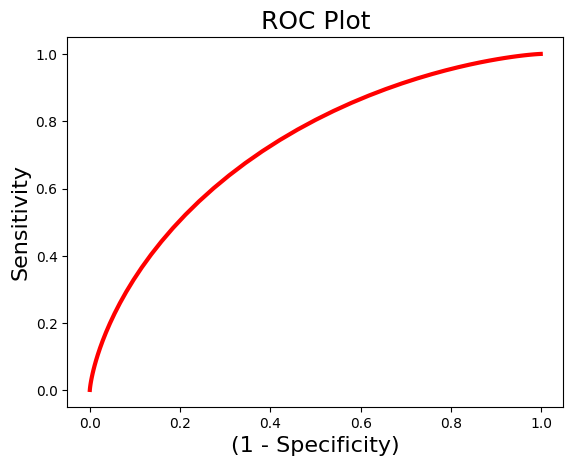

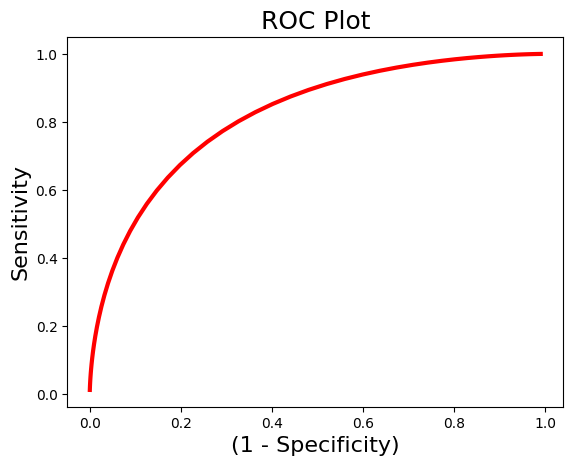

In [71]:
dc_stats = dc_data.predict(algorithm='svm', 
                           cv_dict={'type':'loso', 'subject_id': subject_id},
                           **{'kernel':"linear"}, plot=False, verbose=0)


roc = Roc(input_values=dc_stats['dist_from_hyperplane_xval'],
          binary_outcome=dc_stats['Y'].astype(bool))

roc_fig = roc.plot()
roc.summary()


roc_fc = Roc(input_values=dc_stats['dist_from_hyperplane_xval'],
            binary_outcome=dc_stats['Y'].astype(bool), forced_choice=subject_id)
roc_fc.plot()
roc_fc.summary()

svm_result_list.append({'ROI': 'whole_brain_dc', 'CV accuracy': dc_stats['mcr_xval'], \
                        'ROC_accuracy': roc.accuracy, 'ROC_accuracy_se': roc.accuracy_se, \
                        'ROC_accuracy_p_value': roc.accuracy_p.pvalue, 'ROC_accuracy_p': roc.accuracy_p,\
                        'ROC_sensitivity': roc.sensitivity, 'ROC_specificity': roc.specificity, 'ROC_AUC': roc.auc, 'ROC_PPV': roc.ppv,\
                        'ROC_FC_accuracy': roc_fc.accuracy, 'ROC_FC_accuracy_se': roc_fc.accuracy_se, \
                        'ROC_FC_accuracy_p_value': roc_fc.accuracy_p.pvalue, 'ROC_FC_accuracy_p': roc_fc.accuracy_p,\
                        'ROC_FC_sensitivity': roc_fc.sensitivity, \
                        'ROC_FC_specificity': roc_fc.specificity, 'ROC_FC_AUC': roc_fc.auc, 'ROC_FC_PPV': roc_fc.ppv})

Plotting unthresholded image


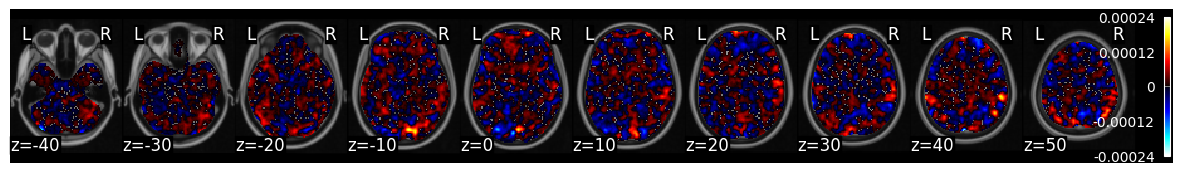

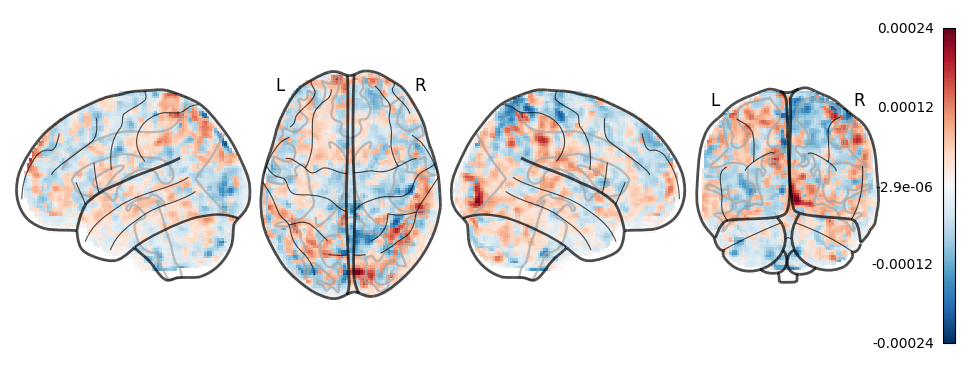

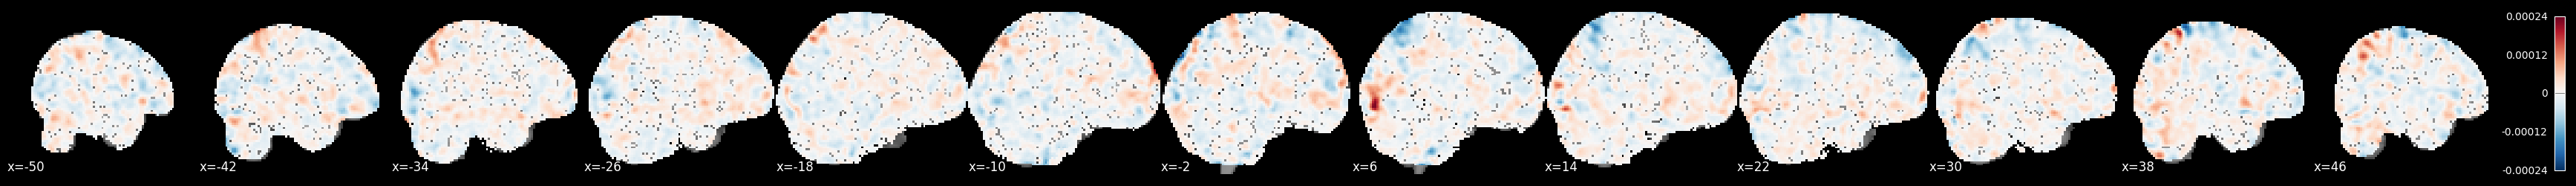

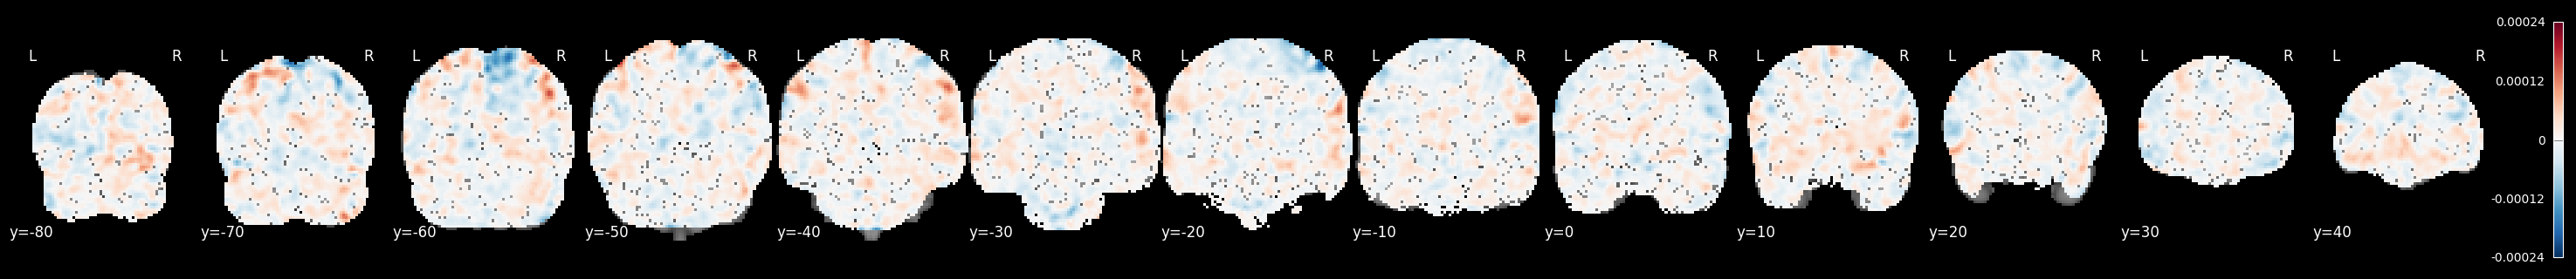

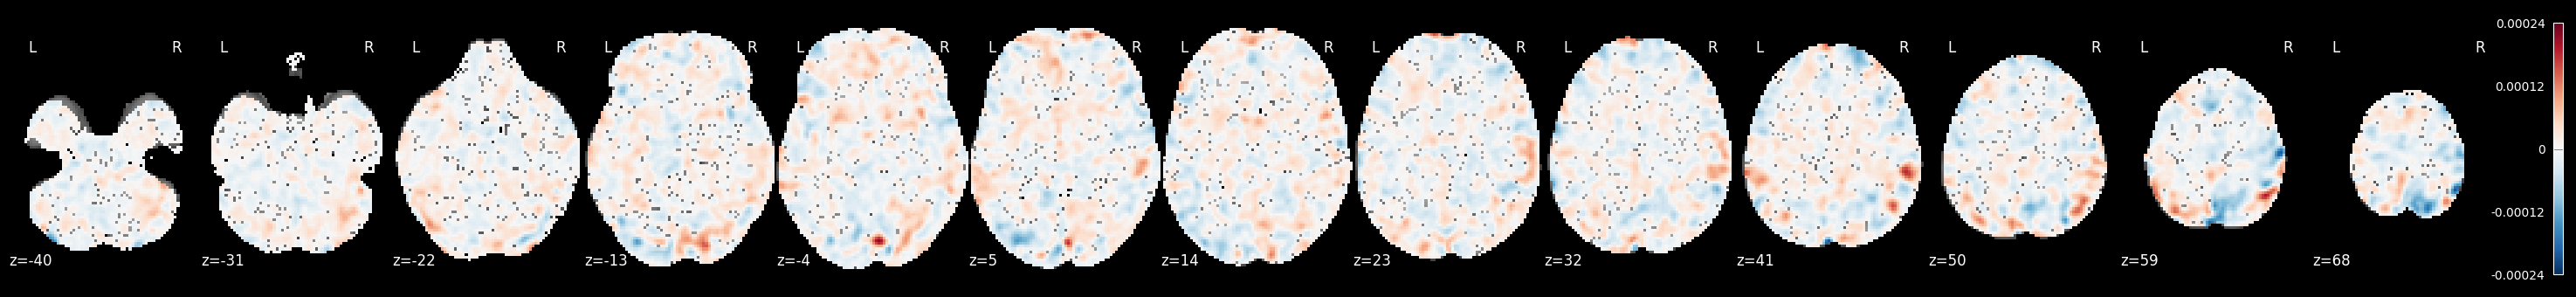

In [72]:
### 可用于后续neurosynth decoding分析

dc_stats['weight_map'].write(mvpa_path + 'dc_weight_map_241116.nii.gz')

dc_stats['weight_map'].plot(colorbar = True)

plot_brain(dc_stats['weight_map'])

## Risky Data

<Axes: xlabel='Y', ylabel='decision'>

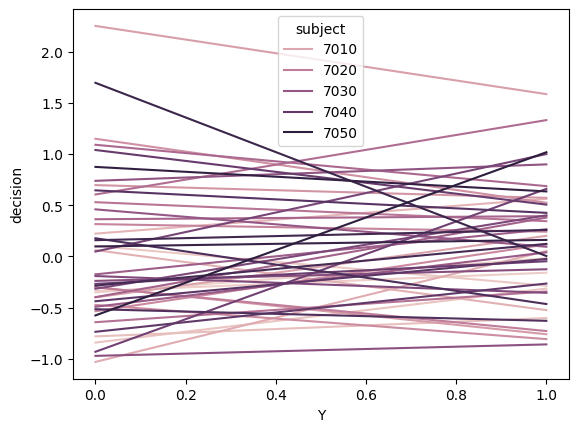

In [31]:
sns.lineplot(
    data=check_df,
    x="Y",
    y="decision",
    hue="subject",
    estimator=None
)

In [23]:
# 1. subject_id 是否和 oo_data 每一行完全对应
assert len(subject_id) == oo_data.shape()[0]
print(pd.Series(subject_id).value_counts().head())

# 2. Y 是否真的是 0/1，而不是 -1/1 或字符串
print(np.unique(oo_stats["Y"], return_counts=True))

# 3. astype(bool) 是否出错
y = np.asarray(oo_stats["Y"]).astype(int)
binary_y = y == 1
print(np.unique(binary_y, return_counts=True))

# 4. 每个被试是否都有两类样本
tmp = pd.DataFrame({
    "subject": subject_id,
    "Y": y
})
print(pd.crosstab(tmp["subject"], tmp["Y"]))

7001    2
7039    2
7030    2
7031    2
7032    2
Name: count, dtype: int64
(array([0, 1], dtype=int64), array([46, 46], dtype=int64))
(array([False,  True]), array([46, 46], dtype=int64))
Y        0  1
subject      
7001     1  1
7002     1  1
7003     1  1
7004     1  1
7005     1  1
7007     1  1
7008     1  1
7009     1  1
7011     1  1
7012     1  1
7013     1  1
7014     1  1
7015     1  1
7016     1  1
7017     1  1
7018     1  1
7020     1  1
7022     1  1
7023     1  1
7024     1  1
7025     1  1
7026     1  1
7027     1  1
7028     1  1
7029     1  1
7030     1  1
7031     1  1
7032     1  1
7033     1  1
7034     1  1
7035     1  1
7036     1  1
7037     1  1
7038     1  1
7039     1  1
7040     1  1
7041     1  1
7042     1  1
7043     1  1
7044     1  1
7045     1  1
7046     1  1
7047     1  1
7048     1  1
7049     1  1
7050     1  1


------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           0.63
Accuracy SE:        0.07
Accuracy p-value:   0.02
Sensitivity:        0.72
Specificity:        0.54
AUC:                0.58
PPV:                0.61
------------------------
------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           0.59
Accuracy SE:        0.09
Accuracy p-value:   0.30
Sensitivity:        0.58
Specificity:        0.58
AUC:                0.58
PPV:                0.58
------------------------


NameError: name 'svm_result_list' is not defined

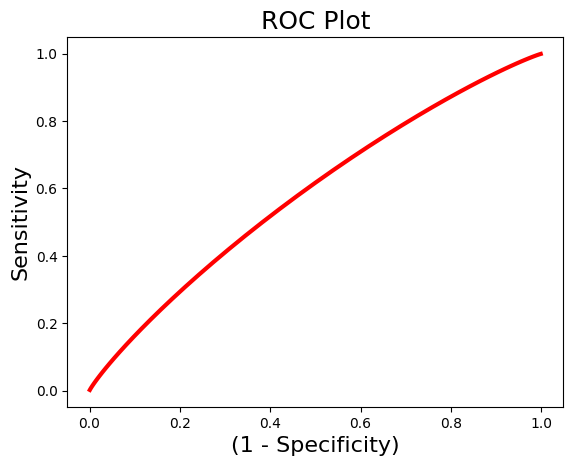

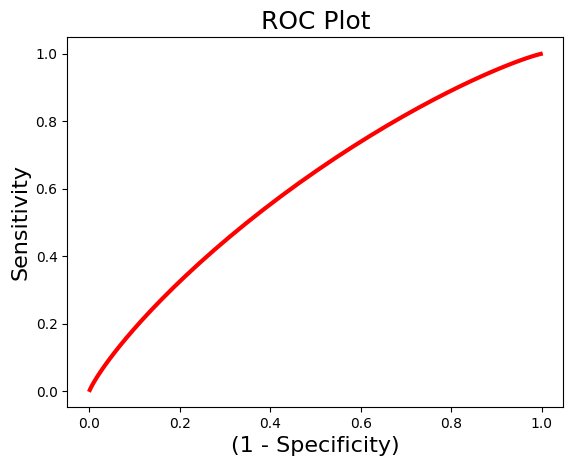

In [22]:
oo_stats = oo_data.predict(algorithm='svm', 
                           cv_dict={'type':'loso', 'subject_id': subject_id},
                           **{'kernel':"linear"}, plot=False, verbose=0)


roc = Roc(input_values=oo_stats['dist_from_hyperplane_xval'],
          binary_outcome=oo_stats['Y'].astype(bool))
roc.plot()
roc.summary()

roc_fc = Roc(input_values=oo_stats['dist_from_hyperplane_xval'],
            binary_outcome=oo_stats['Y'].astype(bool), forced_choice=subject_id)
roc_fc.plot() 
roc_fc.summary()

svm_result_list.append({'ROI': 'whole_brain_oo', 'CV accuracy': oo_stats['mcr_xval'], \
                        'ROC_accuracy': roc.accuracy, 'ROC_accuracy_se': roc.accuracy_se, \
                        'ROC_accuracy_p_value': roc.accuracy_p.pvalue, 'ROC_accuracy_p': roc.accuracy_p,\
                        'ROC_sensitivity': roc.sensitivity, 'ROC_specificity': roc.specificity, 'ROC_AUC': roc.auc, 'ROC_PPV': roc.ppv,\
                        'ROC_FC_accuracy': roc_fc.accuracy, 'ROC_FC_accuracy_se': roc_fc.accuracy_se, \
                        'ROC_FC_accuracy_p_value': roc_fc.accuracy_p.pvalue, 'ROC_FC_accuracy_p': roc_fc.accuracy_p,\
                        'ROC_FC_sensitivity': roc_fc.sensitivity, \
                        'ROC_FC_specificity': roc_fc.specificity, 'ROC_FC_AUC': roc_fc.auc, 'ROC_FC_PPV': roc_fc.ppv})

Plotting unthresholded image


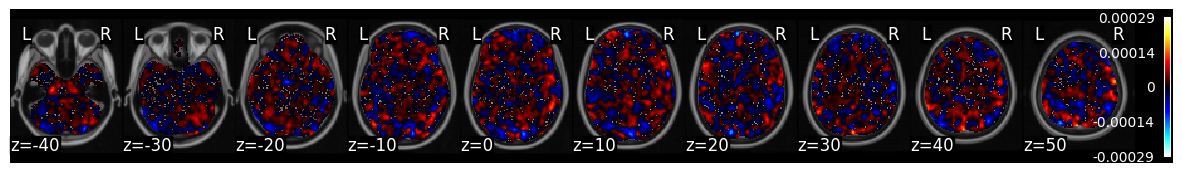

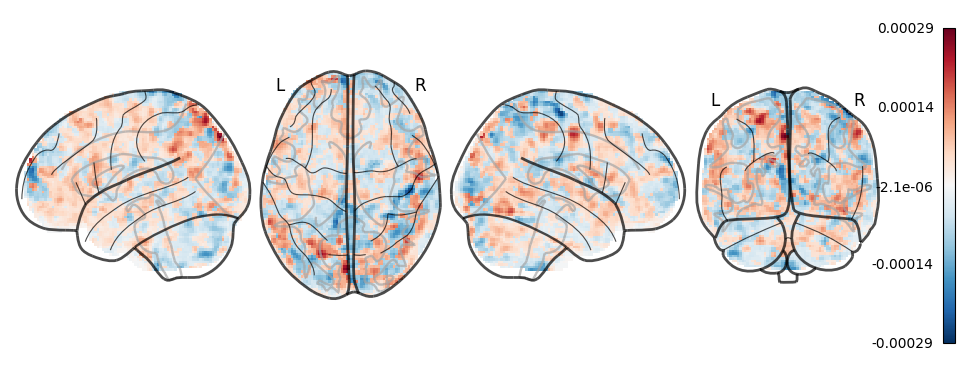

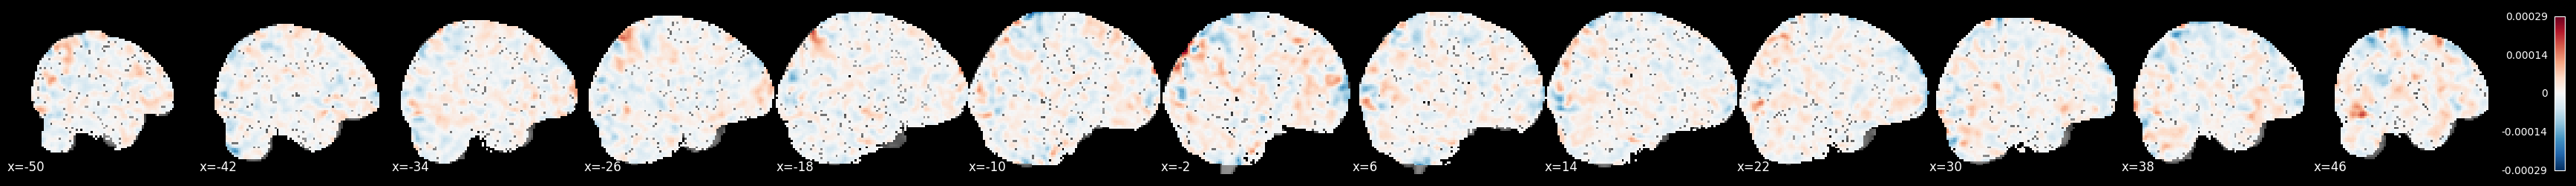

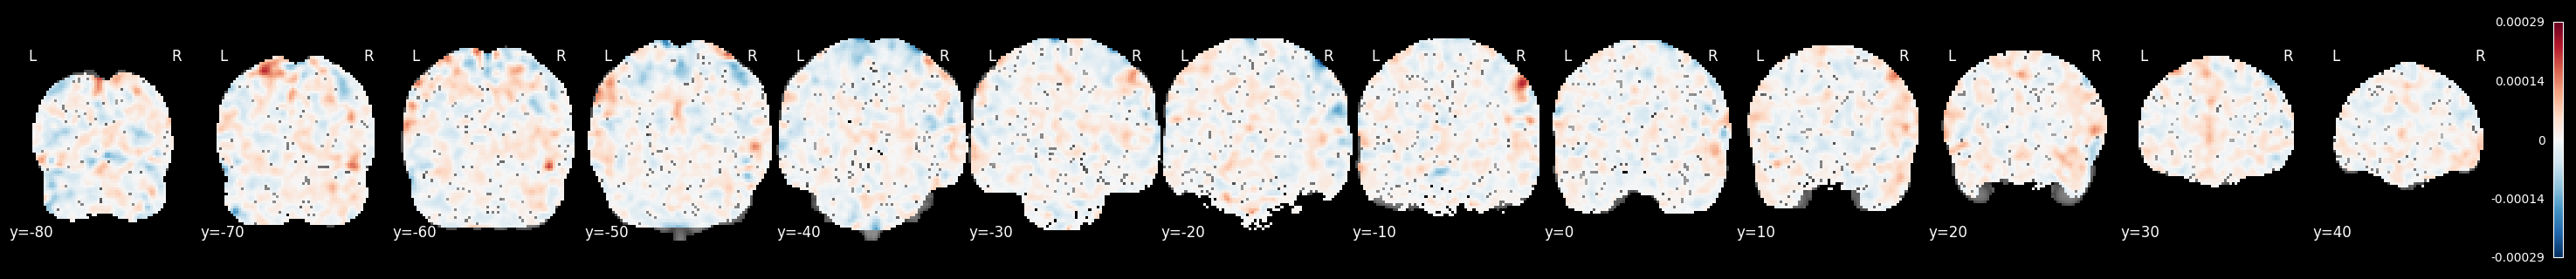

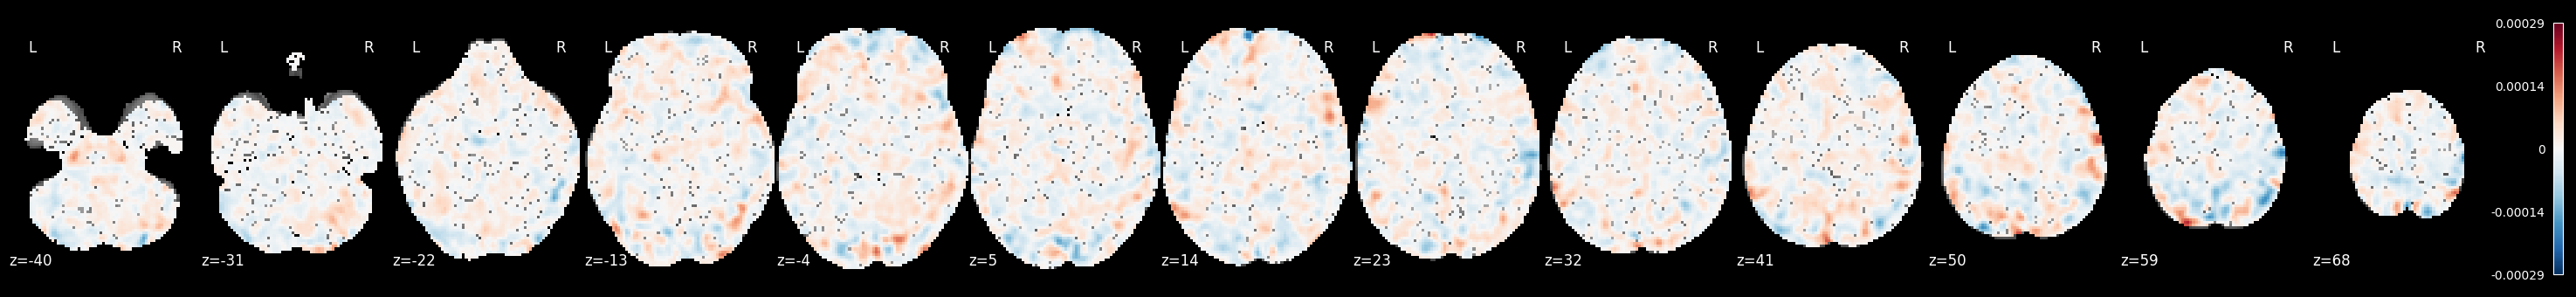

In [74]:
### 可用于后续neurosynth decoding分析

oo_stats['weight_map'].write(mvpa_path + 'oo_weight_map_241116.nii.gz')

oo_stats['weight_map'].plot(colorbar = True)

plot_brain(oo_stats['weight_map'])

In [75]:
svm_result_df = pd.DataFrame(svm_result_list)

svm_result_df.to_csv(mvpa_path + 'svm_results_241116_wholebrain.csv', index=False)

## Classification with Cross-Validation

In [18]:
cross_svm_result_list = []

In [19]:
import seaborn as sns

### Certain Classifier classifies Certain and Risky

In [37]:
dc_wmap_data = image.load_img(mvpa_path + 'dc_weight_map_241116.nii.gz')

dc_wmap = Brain_Data(dc_wmap_data) # nltools data

------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           0.63
Accuracy SE:        0.07
Accuracy p-value:   0.02
Sensitivity:        0.70
Specificity:        0.57
AUC:                0.60
PPV:                0.62
------------------------
------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           0.63
Accuracy SE:        0.09
Accuracy p-value:   0.10
Sensitivity:        0.61
Specificity:        0.61
AUC:                0.61
PPV:                0.61
------------------------


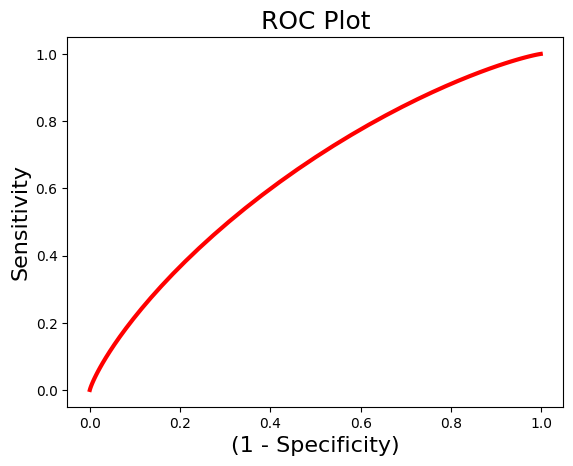

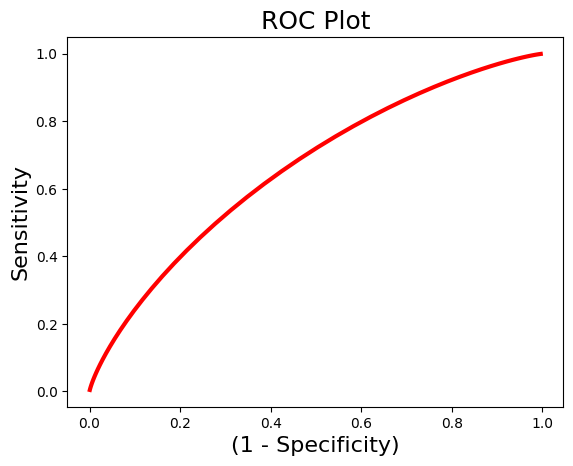

In [38]:
import numpy as np
from nltools.analysis import Roc

# test set: oo / risky / uncertain
y_test = np.asarray(oo_stats["Y"]).astype(int)
binary_y_test = y_test == 1

subject_id = np.asarray(subject_id)

assert len(binary_y_test) == oo_data.shape()[0]
assert len(subject_id) == oo_data.shape()[0]

# certain-trained classifier weight applied to oo/risky data
cross_decision = oo_data.similarity(dc_wmap, "dot_product")

cross_roc = Roc(
    input_values=cross_decision,
    binary_outcome=binary_y_test
)
cross_roc.plot()
cross_roc.summary()

cross_roc_fc = Roc(
    input_values=cross_decision,
    binary_outcome=binary_y_test,
    forced_choice=subject_id
)
cross_roc_fc.plot()
cross_roc_fc.summary()

------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           0.63
Accuracy SE:        0.07
Accuracy p-value:   0.02
Sensitivity:        0.70
Specificity:        0.57
AUC:                0.60
PPV:                0.62
------------------------
------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           0.63
Accuracy SE:        0.09
Accuracy p-value:   0.10
Sensitivity:        0.61
Specificity:        0.61
AUC:                0.61
PPV:                0.61
------------------------


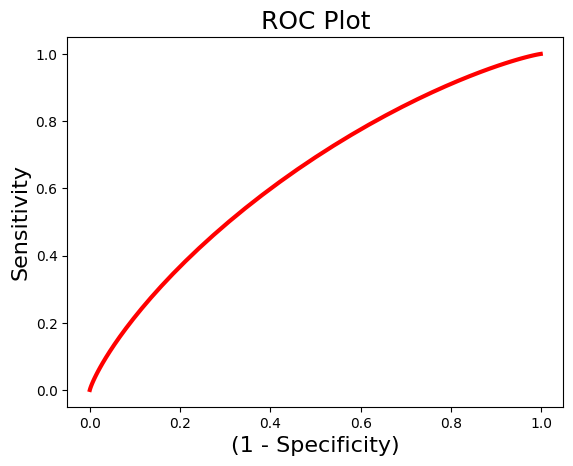

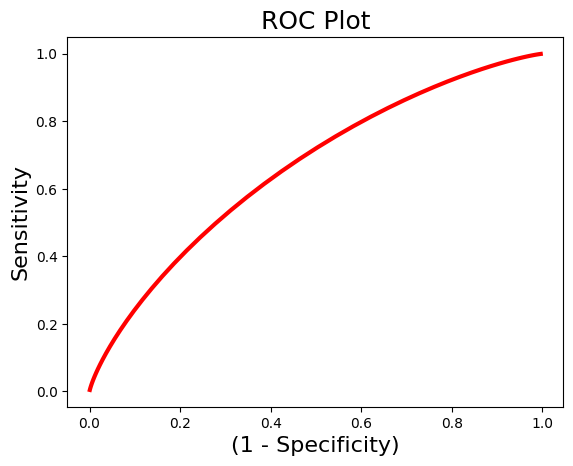

In [79]:
certain_classify_certain_1 = dc_data.similarity(dc_wmap,'dot_product')
certain_classify_risky_1 = oo_data.similarity(dc_wmap,'dot_product')

##################################### dc
cross_roc_1 = Roc(input_values= certain_classify_risky_1,
                binary_outcome=oo_stats['Y'].astype(bool))
cross_roc_1.plot()
cross_roc_1.summary()

cross_roc_fc_1 = Roc(input_values= certain_classify_risky_1,
                    binary_outcome=oo_stats['Y'].astype(bool), forced_choice=subject_id)
cross_roc_fc_1.plot()
cross_roc_fc_1.summary()

In [21]:
##################################### dc
certain_classify_certain = dc_data.similarity(dc_wmap,'correlation')
certain_classify_risky = oo_data.similarity(dc_wmap,'correlation')

certain_c_certain_dat = pd.DataFrame(data={'SubjectID': dc_data.X['subID'],
                            'Predicted Value': certain_classify_certain,
                            'Condition': dc_data.X['Condition_name']})

certain_c_risky_dat = pd.DataFrame(data={'SubjectID': dc_data.X['subID'],
                            'Predicted Value': certain_classify_risky,
                            'Condition': dc_data.X['Condition_name']})

NameError: name 'dc_data' is not defined

In [81]:
dc_data.X['Condition_name']

0     DC2
1     DC2
2     DC2
3     DC2
4     DC2
     ... 
87    DC8
88    DC8
89    DC8
90    DC8
91    DC8
Name: Condition_name, Length: 92, dtype: object

In [82]:
certain_c_risky_dat['Condition']

0     DC2
1     DC2
2     DC2
3     DC2
4     DC2
     ... 
87    DC8
88    DC8
89    DC8
90    DC8
91    DC8
Name: Condition, Length: 92, dtype: object

In [83]:
from scipy import stats

a = np.array(certain_c_risky_dat[certain_c_risky_dat['Condition']=='DC2']['Predicted Value'])
b = np.array(certain_c_risky_dat[certain_c_risky_dat['Condition']=='DC8']['Predicted Value'])

stats.ttest_rel(a,b)

TtestResult(statistic=-1.737766840671818, pvalue=0.08909188216020687, df=45)

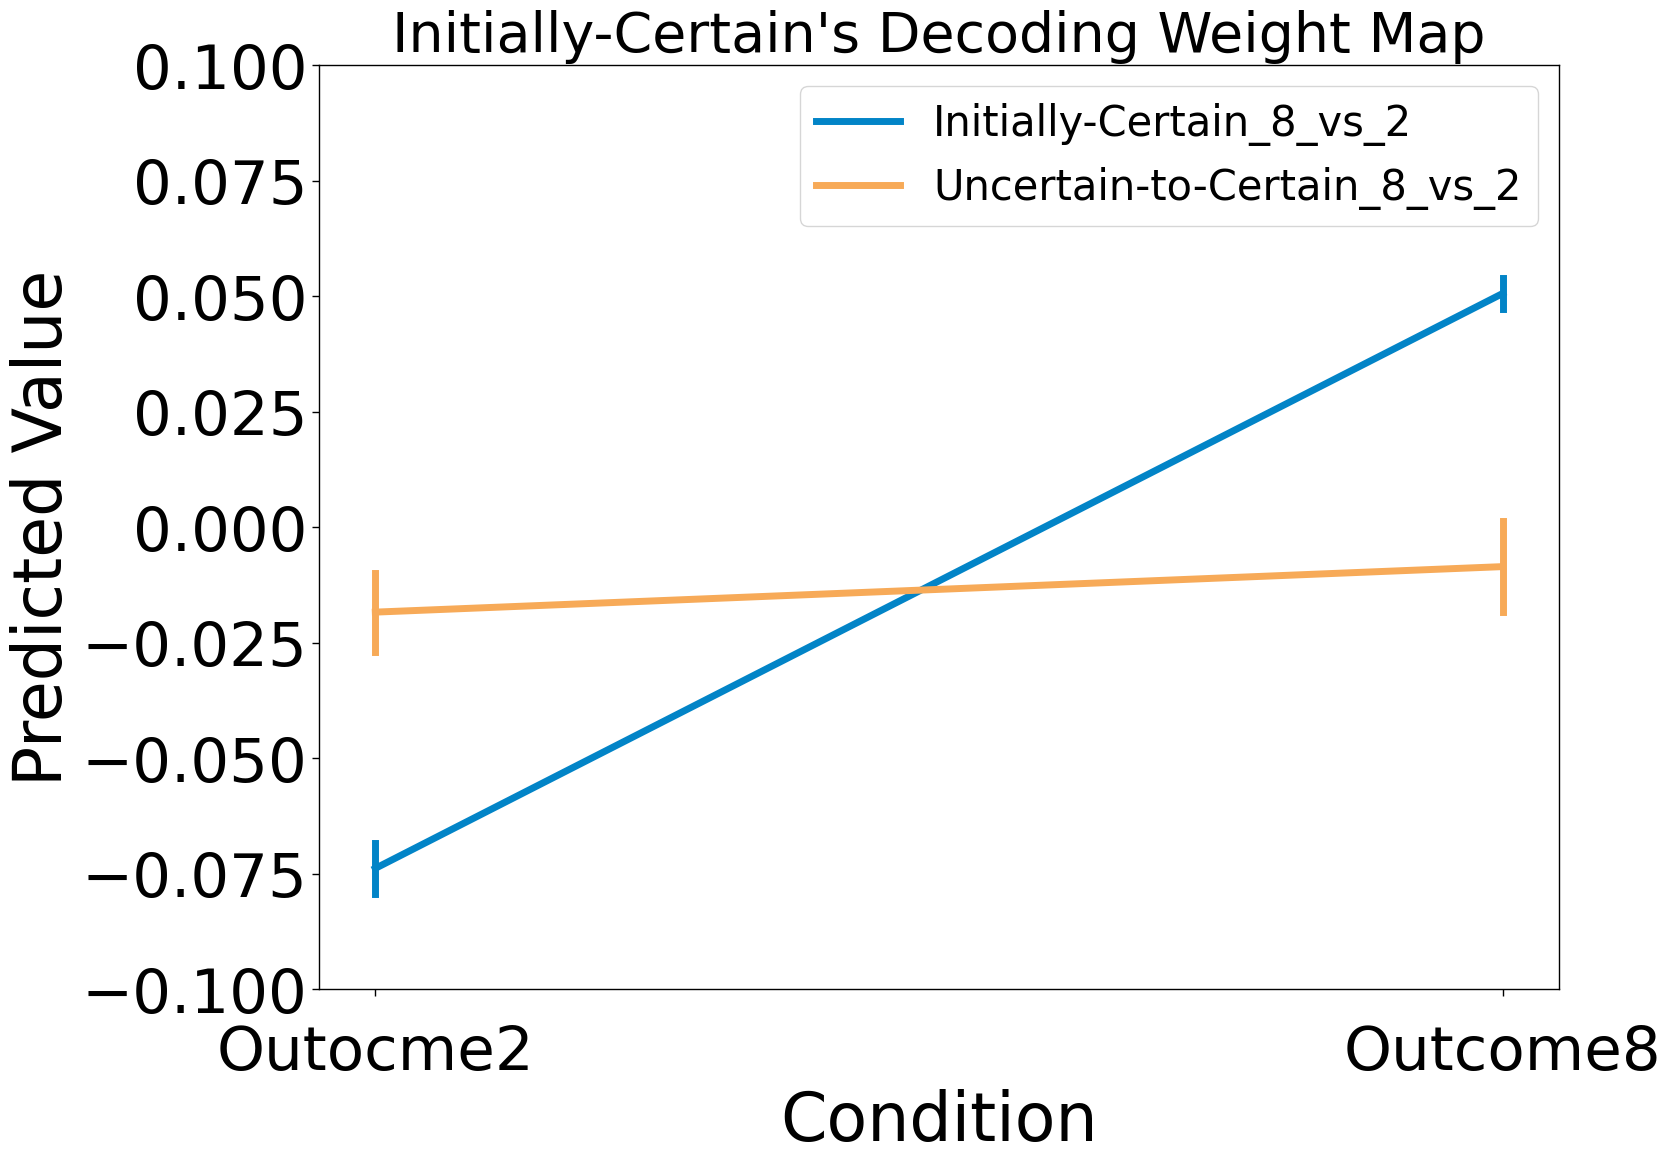

In [45]:
###################################### 这一部分存疑...
# 创建一个图形对象并设置大小
plt.figure(figsize=(16, 12))

line_width = 5

with sns.plotting_context(context='paper',font_scale=5):
    ax = sns.lineplot(data=certain_c_certain_dat, x='Condition', y='Predicted Value', err_style="bars", errorbar=("se", 2), 
                      color = "#0284C7", label = "Initially-Certain_8_vs_2", linewidth=line_width)
    
with sns.plotting_context(context='paper',font_scale=5):
    ax = sns.lineplot(data= certain_c_risky_dat, x='Condition', y='Predicted Value', err_style="bars", errorbar=("se", 2), 
                 color = "#F7AA58", label = "Uncertain-to-Certain_8_vs_2", linewidth=line_width)
    
    # 获取当前图中的所有误差条对象
    for line in ax.collections:
            line.set_linewidth(line_width)  # 设置误差条的粗细
            
            
plt.yticks(np.arange(-0.1, 0.11, 0.025))  # 设置 y 轴坐标间距
plt.legend(fontsize = 30)  # 显示图例
plt.title('Initially-Certain\'s Decoding Weight Map', fontsize = 40, pad = 10)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Outocme2', 'Outcome8'])
plt.tick_params(axis='x', pad=20)  # labelpad设置标签与刻度的距离


# 调整标题和图之间的间距
# plt.subplots_adjust(top=1)  # 可根据需要调整间距

# 保存图片
plt.savefig(fig_path + 'dc_cross_validation_241116.pdf', dpi = 300)

------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           1.00
Accuracy SE:        0.10
Accuracy p-value:   0.00
Sensitivity:        1.00
Specificity:        1.00
AUC:                1.00
PPV:                1.00
------------------------
------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           1.00
Accuracy SE:        0.15
Accuracy p-value:   0.00
Sensitivity:        1.00
Specificity:        1.00
AUC:                1.00
PPV:                1.00
------------------------


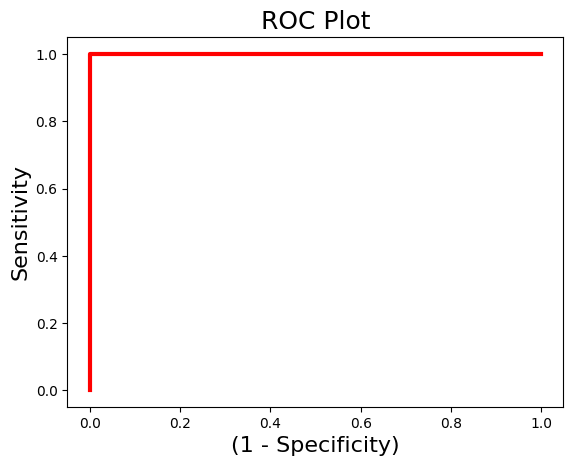

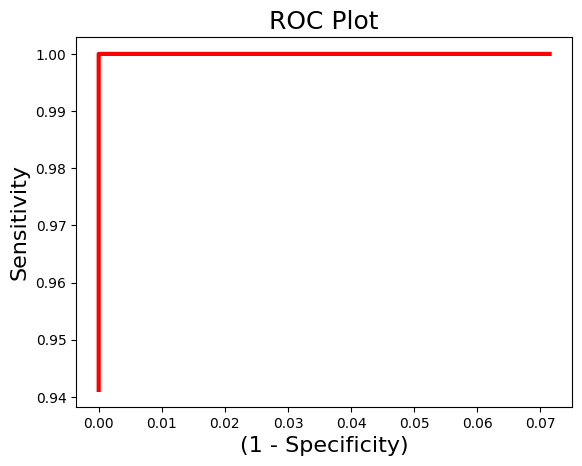

In [84]:
#### cross-situation ROC
##################################### dc
cross_roc = Roc(input_values= certain_classify_certain,
                binary_outcome=oo_stats['Y'].astype(bool))
cross_roc.plot()
cross_roc.summary()

cross_roc_fc = Roc(input_values= certain_classify_certain,
                    binary_outcome=oo_stats['Y'].astype(bool), forced_choice=subject_id)
cross_roc_fc.plot()
cross_roc_fc.summary()

------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           0.63
Accuracy SE:        0.07
Accuracy p-value:   0.02
Sensitivity:        0.72
Specificity:        0.54
AUC:                0.61
PPV:                0.61
------------------------
------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           0.61
Accuracy SE:        0.09
Accuracy p-value:   0.18
Sensitivity:        0.60
Specificity:        0.60
AUC:                0.60
PPV:                0.60
------------------------


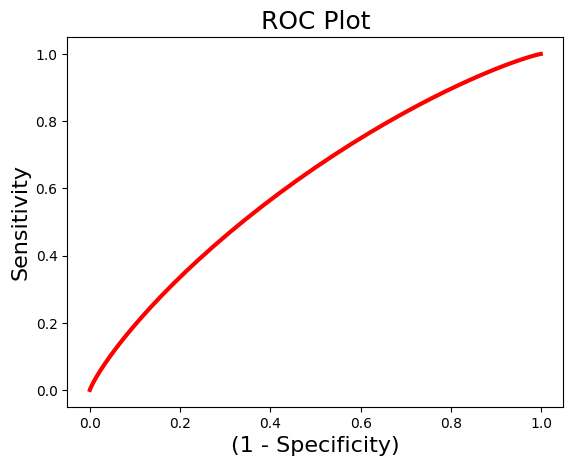

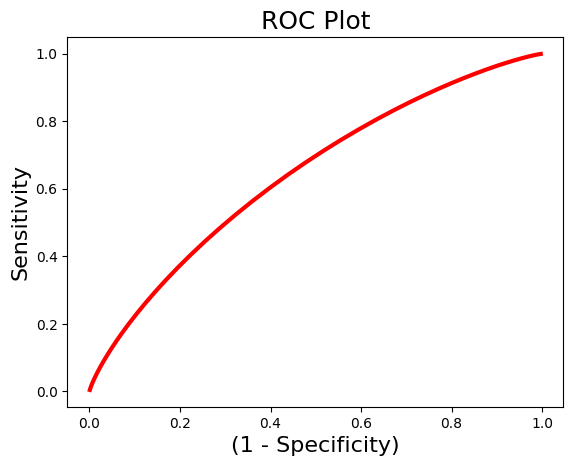

In [85]:
#### cross-situation ROC
##################################### dc
cross_roc = Roc(input_values= certain_classify_risky,
                binary_outcome=oo_stats['Y'].astype(bool))
cross_roc.plot()
cross_roc.summary()

cross_roc_fc = Roc(input_values= certain_classify_risky,
                    binary_outcome=oo_stats['Y'].astype(bool), forced_choice=subject_id)
cross_roc_fc.plot()
cross_roc_fc.summary()

cross_svm_result_list.append({'condition': 'certain_classify_risky', \
                        'ROC_accuracy': cross_roc.accuracy, 'ROC_accuracy_se': cross_roc.accuracy_se, \
                        'ROC_accuracy_p_value': cross_roc.accuracy_p.pvalue, 'ROC_accuracy_p': cross_roc.accuracy_p,\
                        'ROC_sensitivity': cross_roc.sensitivity, 'ROC_specificity': cross_roc.specificity, \
                        'ROC_AUC': cross_roc.auc, 'ROC_PPV': cross_roc.ppv,\
                        'ROC_FC_accuracy': cross_roc_fc.accuracy, 'ROC_FC_accuracy_se': cross_roc_fc.accuracy_se, \
                        'ROC_FC_accuracy_p_value': cross_roc_fc.accuracy_p.pvalue, 'ROC_FC_accuracy_p': cross_roc_fc.accuracy_p,\
                        'ROC_FC_sensitivity': cross_roc_fc.sensitivity, \
                        'ROC_FC_specificity': cross_roc_fc.specificity, 'ROC_FC_AUC': cross_roc_fc.auc, 'ROC_FC_PPV': cross_roc_fc.ppv})

### Risky Classifier classifies Certain and Risky

In [32]:
oo_wmap_data = image.load_img(mvpa_path + 'oo_weight_map_241116.nii.gz')

oo_wmap = Brain_Data(oo_wmap_data) # nltools data

NameError: name 'dc_wmap' is not defined

------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           0.67
Accuracy SE:        0.07
Accuracy p-value:   0.00
Sensitivity:        0.67
Specificity:        0.67
AUC:                0.67
PPV:                0.67
------------------------
------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           0.70
Accuracy SE:        0.10
Accuracy p-value:   0.01
Sensitivity:        0.68
Specificity:        0.68
AUC:                0.68
PPV:                0.68
------------------------


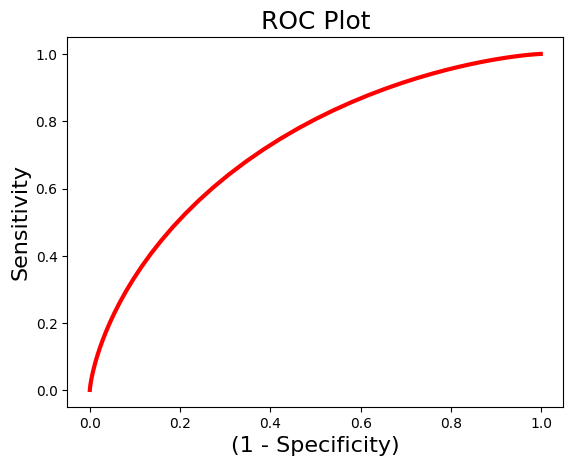

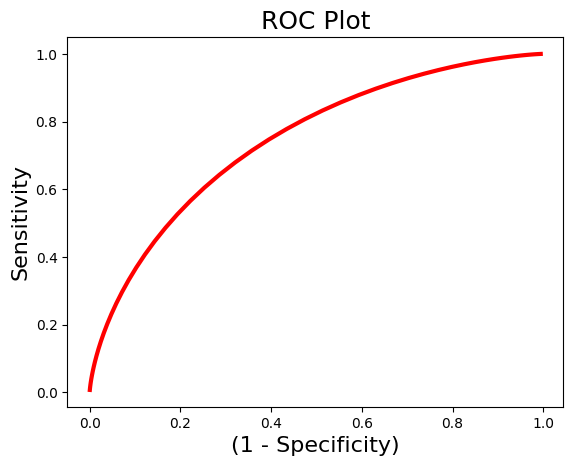

In [87]:
risky_classify_certain_1 = dc_data.similarity(oo_stats['weight_map'],'dot_product')
risky_classify_risky_1 = oo_data.similarity(oo_stats['weight_map'],'dot_product')

##################################### dc
cross_roc_1 = Roc(input_values= risky_classify_certain_1,
                binary_outcome=oo_stats['Y'].astype(bool))
cross_roc_1.plot()
cross_roc_1.summary()

cross_roc_fc_1 = Roc(input_values= risky_classify_certain_1,
                    binary_outcome=oo_stats['Y'].astype(bool), forced_choice=subject_id)
cross_roc_fc_1.plot()
cross_roc_fc_1.summary()

In [88]:
##################################### dc
risky_classify_certain = dc_data.similarity(oo_stats['weight_map'],'correlation') 
risky_classify_risky = oo_data.similarity(oo_stats['weight_map'],'correlation')

risky_c_certain_dat = pd.DataFrame(data={'SubjectID': oo_data.X['subID'],
                            'Predicted Value': risky_classify_certain,
                            'Condition': oo_data.X['Condition_name']})

risky_c_risky_dat = pd.DataFrame(data={'SubjectID': oo_data.X['subID'],
                            'Predicted Value': risky_classify_risky,
                            'Condition': oo_data.X['Condition_name']})

------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           1.00
Accuracy SE:        0.10
Accuracy p-value:   0.00
Sensitivity:        1.00
Specificity:        1.00
AUC:                1.00
PPV:                1.00
------------------------
------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           1.00
Accuracy SE:        0.15
Accuracy p-value:   0.00
Sensitivity:        1.00
Specificity:        1.00
AUC:                1.00
PPV:                1.00
------------------------


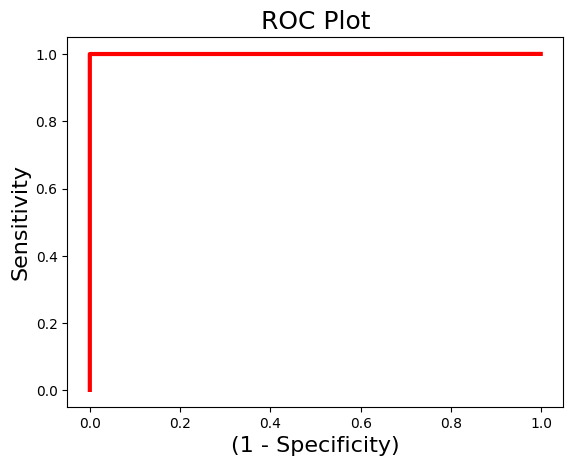

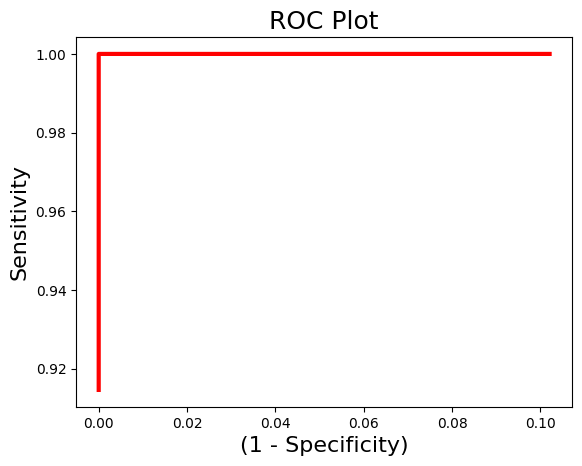

In [89]:
#### cross-situation ROC
cross_roc = Roc(input_values= risky_classify_risky,
                binary_outcome=dc_stats['Y'].astype(bool))
cross_roc.plot()
cross_roc.summary()

cross_roc_fc = Roc(input_values= risky_classify_risky,
                    binary_outcome=dc_stats['Y'].astype(bool), forced_choice=subject_id)
cross_roc_fc.plot()
cross_roc_fc.summary()

------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           0.70
Accuracy SE:        0.07
Accuracy p-value:   0.00
Sensitivity:        0.67
Specificity:        0.72
AUC:                0.68
PPV:                0.70
------------------------
------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           0.67
Accuracy SE:        0.10
Accuracy p-value:   0.03
Sensitivity:        0.68
Specificity:        0.68
AUC:                0.68
PPV:                0.68
------------------------


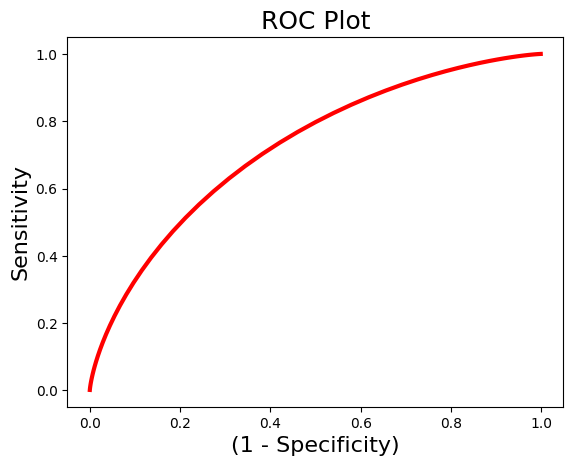

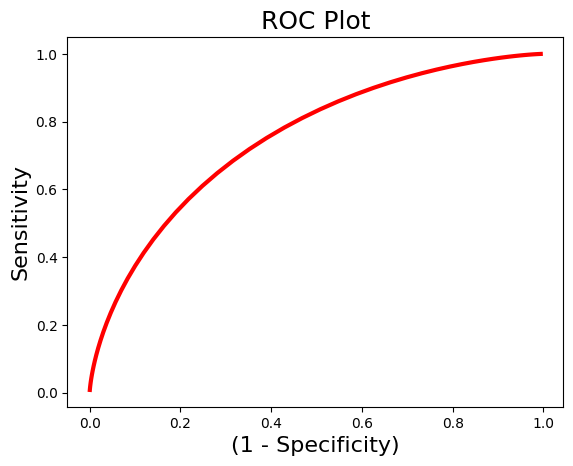

In [90]:
#### cross-situation ROC
cross_roc = Roc(input_values= risky_classify_certain,
                binary_outcome=dc_stats['Y'].astype(bool))
cross_roc.plot()
cross_roc.summary()

cross_roc_fc = Roc(input_values= risky_classify_certain,
                    binary_outcome=dc_stats['Y'].astype(bool), forced_choice=subject_id)
cross_roc_fc.plot()
cross_roc_fc.summary()

cross_svm_result_list.append({'condition': 'risky_classify_certain', \
                        'ROC_accuracy': cross_roc.accuracy, 'ROC_accuracy_se': cross_roc.accuracy_se, \
                        'ROC_accuracy_p_value': cross_roc.accuracy_p.pvalue, 'ROC_accuracy_p': cross_roc.accuracy_p,\
                        'ROC_sensitivity': cross_roc.sensitivity, 'ROC_specificity': cross_roc.specificity, \
                        'ROC_AUC': cross_roc.auc, 'ROC_PPV': cross_roc.ppv,\
                        'ROC_FC_accuracy': cross_roc_fc.accuracy, 'ROC_FC_accuracy_se': cross_roc_fc.accuracy_se, \
                        'ROC_FC_accuracy_p_value': cross_roc_fc.accuracy_p.pvalue, 'ROC_FC_accuracy_p': cross_roc_fc.accuracy_p,\
                        'ROC_FC_sensitivity': cross_roc_fc.sensitivity, \
                        'ROC_FC_specificity': cross_roc_fc.specificity, 'ROC_FC_AUC': cross_roc_fc.auc, 'ROC_FC_PPV': cross_roc_fc.ppv})

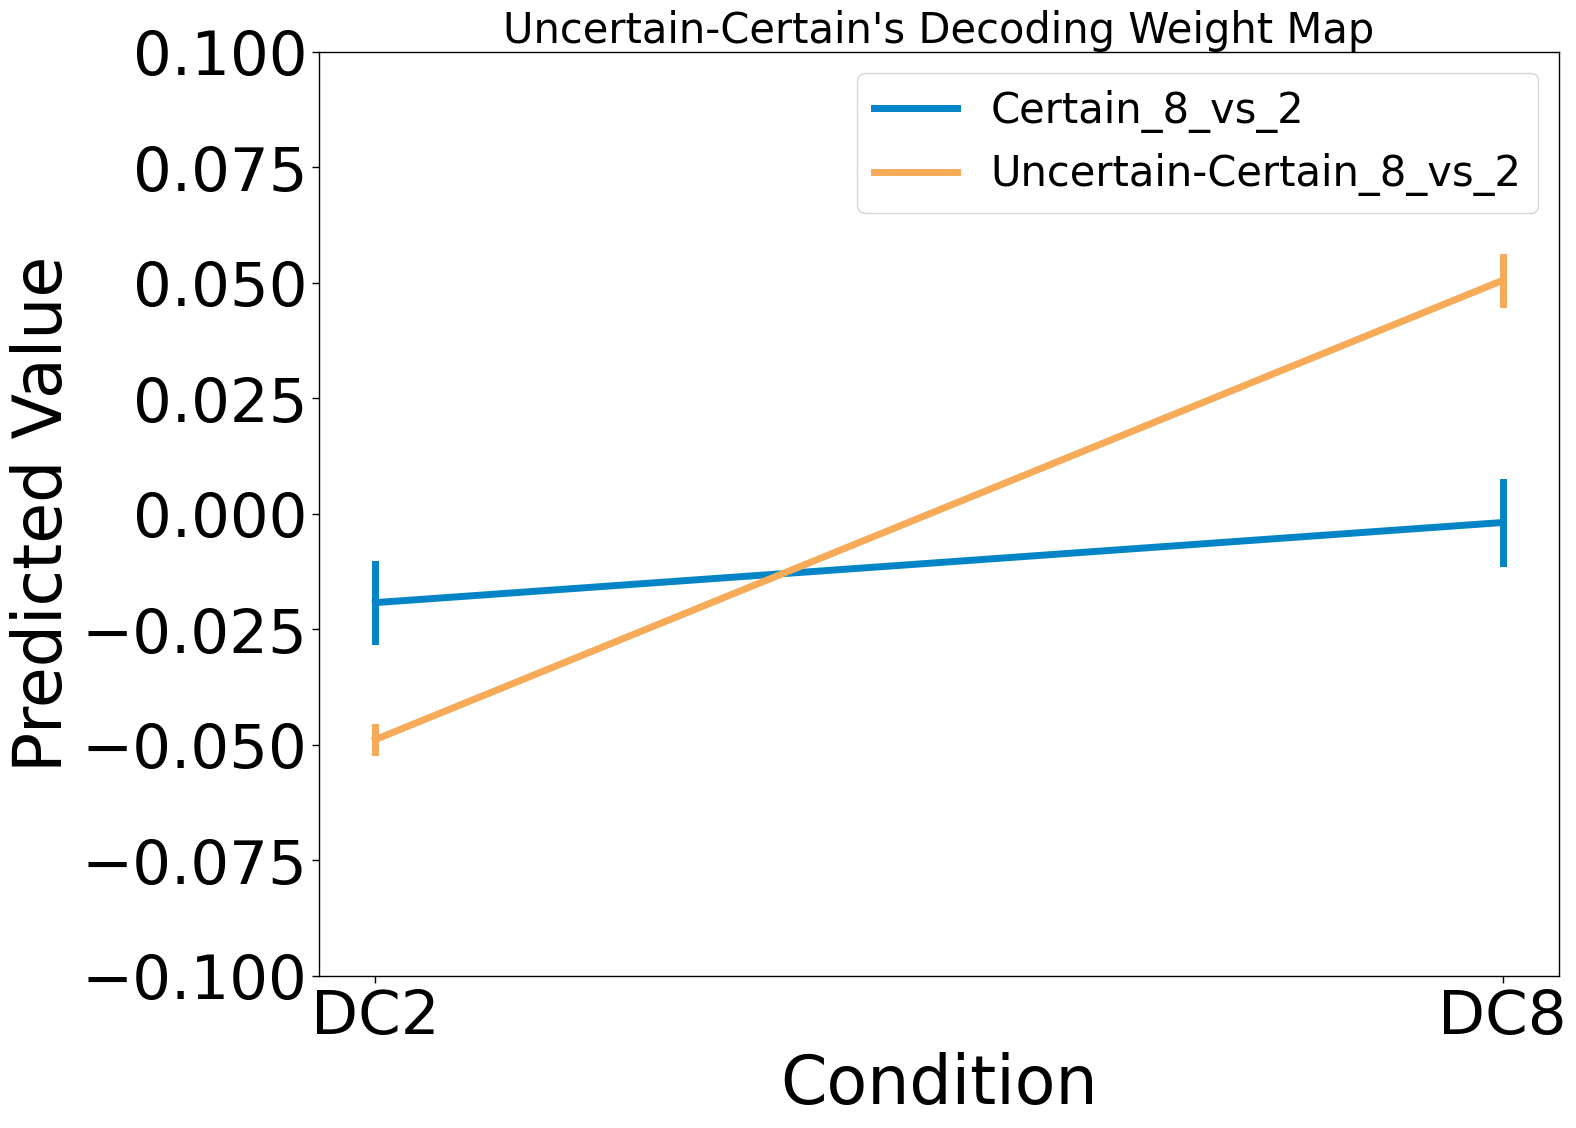

In [29]:
###################################### 这一部分存疑...
# 创建一个图形对象并设置大小
plt.figure(figsize=(16, 12))

line_width = 5

with sns.plotting_context(context='paper',font_scale=5):
    ax = sns.lineplot(data = risky_c_certain_dat, x='Condition', y='Predicted Value', err_style="bars", errorbar=("se", 2), 
                      color = "#0284C7", label = "Certain_8_vs_2", linewidth=line_width)
    
with sns.plotting_context(context='paper',font_scale=5):
    ax = sns.lineplot(data= risky_c_risky_dat, x='Condition', y='Predicted Value', err_style="bars", errorbar=("se", 2), 
                 color = "#F7AA58", label = "Uncertain-Certain_8_vs_2", linewidth=line_width)
    
    # 获取当前图中的所有误差条对象
    for line in ax.collections:
            line.set_linewidth(line_width)  # 设置误差条的粗细
            
            
plt.yticks(np.arange(-0.1, 0.11, 0.025))  # 设置 y 轴坐标间距
plt.legend(fontsize = 30)  # 显示图例
plt.title('Uncertain-Certain\'s Decoding Weight Map', fontsize = 30)

# 调整标题和图之间的间距
# plt.subplots_adjust(top=1)  # 可根据需要调整间距

# 保存图片
plt.savefig(graph_path + 'oo_cross_validation_20240922.png')

------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           0.67
Accuracy SE:        0.07
Accuracy p-value:   0.00
Sensitivity:        0.67
Specificity:        0.67
AUC:                0.67
PPV:                0.67
------------------------
------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           0.70
Accuracy SE:        0.10
Accuracy p-value:   0.01
Sensitivity:        0.68
Specificity:        0.68
AUC:                0.68
PPV:                0.68
------------------------


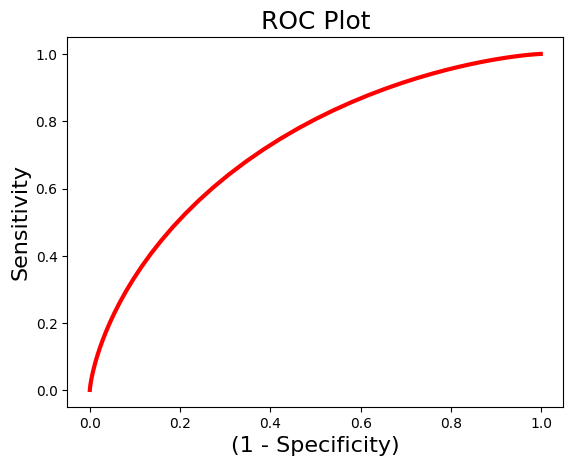

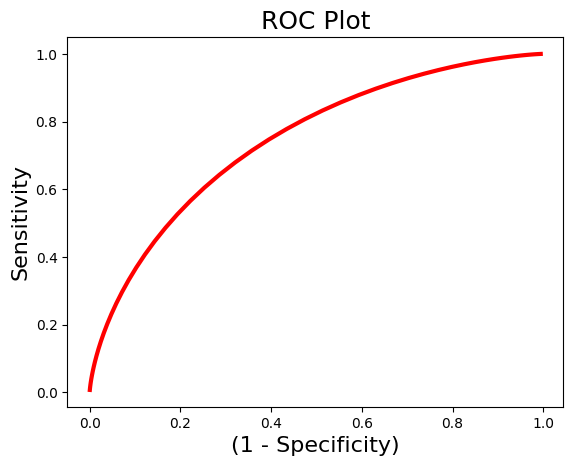

In [68]:
#### cross-situation ROC

cross_roc = Roc(input_values= risky_classify_certain,
                binary_outcome=dc_stats['Y'].astype(bool))
cross_roc.plot()
cross_roc.summary()

cross_roc_fc = Roc(input_values= risky_classify_certain,
                    binary_outcome=dc_stats['Y'].astype(bool), forced_choice=subject_id)
cross_roc_fc.plot()
cross_roc_fc.summary()

cross_svm_result_list.append({'condition': 'risky_classify_certain', \
                        'ROC_accuracy': cross_roc.accuracy, 'ROC_accuracy_se': cross_roc.accuracy_se, \
                        'ROC_accuracy_p_value': cross_roc.accuracy_p.pvalue, 'ROC_accuracy_p': cross_roc.accuracy_p,\
                        'ROC_sensitivity': cross_roc.sensitivity, 'ROC_specificity': cross_roc.specificity, \
                        'ROC_AUC': cross_roc.auc, 'ROC_PPV': cross_roc.ppv,\
                        'ROC_FC_accuracy': cross_roc_fc.accuracy, 'ROC_FC_accuracy_se': cross_roc_fc.accuracy_se, \
                        'ROC_FC_accuracy_p_value': cross_roc_fc.accuracy_p.pvalue, 'ROC_FC_accuracy_p': cross_roc_fc.accuracy_p,\
                        'ROC_FC_sensitivity': cross_roc_fc.sensitivity, \
                        'ROC_FC_specificity': cross_roc_fc.specificity, 'ROC_FC_AUC': cross_roc_fc.auc, 'ROC_FC_PPV': cross_roc_fc.ppv})

In [89]:
cross_svm_result_df = pd.DataFrame(cross_svm_result_list)

cross_svm_result_df.to_csv(mvpa_path + 'cross_svm_results_241116_wholebrain.csv', index=False)

## Pattern Expression
这一步可以最后再做

### Read Brain Data

In [8]:
d2_nilearn_data = image.load_img(c2_nifti_files)

d2_data = Brain_Data(d2_nilearn_data) # nltools data

r2_nilearn_data = image.load_img(r2_nifti_files)

r2_data = Brain_Data(r2_nilearn_data) # nltools data

d8_nilearn_data = image.load_img(c8_nifti_files)

d8_data = Brain_Data(d8_nilearn_data) # nltools data

r8_nilearn_data = image.load_img(r8_nifti_files)

r8_data = Brain_Data(r8_nilearn_data) # nltools data

c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\nilearn\maskers\nifti_masker.py:110: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\nilearn\maskers\nifti_masker.py:110: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\nilearn\maskers\nifti_masker.py:110: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affin

In [9]:
print(d2_data)
print(d8_data)
print(r2_data)
print(r8_data)

nltools.data.brain_data.Brain_Data(data=(46, 238955), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)
nltools.data.brain_data.Brain_Data(data=(46, 238955), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)
nltools.data.brain_data.Brain_Data(data=(46, 238955), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)
nltools.data.brain_data.Brain_Data(data=(46, 238955), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)


### Certain Classifier

In [10]:
# load brain data
dc_stats_data = image.load_img(mvpa_path + 'dc_weight_map_241116.nii.gz')

dc_stats_wmap = Brain_Data(dc_stats_data)

oo_stats_data = image.load_img(mvpa_path + 'oo_weight_map_241116.nii.gz')

oo_stats_wmap = Brain_Data(oo_stats_data)

In [11]:
print(dc_stats_wmap)

nltools.data.brain_data.Brain_Data(data=(238955,), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)


In [13]:
##################################### dc
certain_classify_c2 = d2_data.similarity(dc_stats_wmap,'correlation')
certain_classify_c8 = d8_data.similarity(dc_stats_wmap,'correlation')
certain_classify_r2 = r2_data.similarity(dc_stats_wmap,'correlation')
certain_classify_r8 = r8_data.similarity(dc_stats_wmap,'correlation')

c2_df = pd.DataFrame(certain_classify_c2,columns = ["similarity"])
c2_df["situation"] = "certain"
c2_df["cost"] = "two"

c8_df = pd.DataFrame(certain_classify_c8,columns = ["similarity"])
c8_df["situation"] = "certain"
c8_df["cost"] = "eight"

r2_df = pd.DataFrame(certain_classify_r2,columns = ["similarity"])
r2_df["situation"] = "risky"
r2_df["cost"] = "two"

r8_df = pd.DataFrame(certain_classify_r8,columns = ["similarity"])
r8_df["situation"] = "risky"
r8_df["cost"] = "eight"

certain_class_df = pd.concat([c2_df, c8_df, r2_df, r8_df], axis=0, ignore_index=True)

print(certain_class_df)

     similarity situation   cost
0     -0.059087   certain    two
1     -0.049863   certain    two
2     -0.080671   certain    two
3     -0.079797   certain    two
4     -0.119700   certain    two
..          ...       ...    ...
179   -0.018978     risky  eight
180    0.036512     risky  eight
181   -0.069938     risky  eight
182    0.001239     risky  eight
183    0.043691     risky  eight

[184 rows x 3 columns]


In [14]:
certain_class_df.to_excel(result_dir + 'certain_svm_expression_241119.xlsx', index = False)

### Risky Classifer

In [15]:
##################################### dc
risky_classify_c2 = d2_data.similarity(oo_stats_wmap,'correlation')
risky_classify_c8 = d8_data.similarity(oo_stats_wmap,'correlation')
risky_classify_r2 = r2_data.similarity(oo_stats_wmap,'correlation')
risky_classify_r8 = r8_data.similarity(oo_stats_wmap,'correlation')

c2_df = pd.DataFrame(risky_classify_c2,columns = ["similarity"])
c2_df["situation"] = "certain"
c2_df["cost"] = "two"

c8_df = pd.DataFrame(risky_classify_c8,columns = ["similarity"])
c8_df["situation"] = "certain"
c8_df["cost"] = "eight"

r2_df = pd.DataFrame(risky_classify_r2,columns = ["similarity"])
r2_df["situation"] = "risky"
r2_df["cost"] = "two"

r8_df = pd.DataFrame(risky_classify_r8,columns = ["similarity"])
r8_df["situation"] = "risky"
r8_df["cost"] = "eight"

risky_class_df = pd.concat([c2_df, c8_df, r2_df, r8_df], axis=0, ignore_index=True)

print(risky_class_df)

     similarity situation   cost
0     -0.040061   certain    two
1     -0.021161   certain    two
2     -0.018392   certain    two
3     -0.003274   certain    two
4     -0.070522   certain    two
..          ...       ...    ...
179    0.013870     risky  eight
180    0.053169     risky  eight
181    0.052180     risky  eight
182    0.025505     risky  eight
183    0.033647     risky  eight

[184 rows x 3 columns]


In [17]:
risky_class_df.to_excel(result_dir + 'risky_svm_expression_241119.xlsx',  index = False)

# ROIs analysis

## Read the mask

nltools.data.brain_data.Brain_Data(data=(238955,), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)
nltools.data.brain_data.Brain_Data(data=(200, 238955), Y=(0, 0), X=(200, 1), mask=MNI152_T1_2mm_brain_mask.nii.gz)


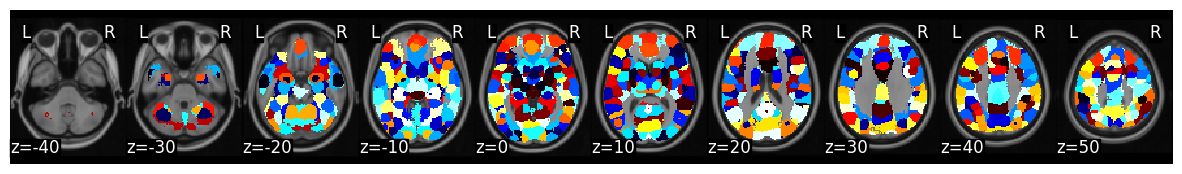

In [52]:
### Mask
maskdir = 'E:\\lxq\\jupyter\\Scripts\\RSA_MVPA\\'
mask = Brain_Data(os.path.join(maskdir,'Neurosynth_Parcellation_2.nii.gz'))
mask.plot()
print(mask)

### Split the mask
mask_all = expand_mask(mask)
# mask_all.plot()

mask_info = glob.glob(os.path.join(maskdir,'mask200_info.csv'))[0]
mask_all.X = pd.read_csv(mask_info)
print(mask_all)

## Certain Data

In [ ]:
### 参考：https://github.com/medianeuroscience/mft_vignettes/blob/main/mvpa/run_mvpa.ipynb

# All clusters
# for k in [52]: 
for k in mask_all.X['Cluster_num']:  
    print('ROI_' + '{:03}'.format(k))
    ROI_mask = mask_all[mask_all.X['Cluster_num'] == k]
    masked_data  = dc_data.apply_mask(ROI_mask)
    masked_data.Y = dc_data.X['Condition']
    svm_stats = masked_data.predict(algorithm='svm', 
                                    cv_dict={'type':'loso', 'subject_id': subject_id},
                                    **{'kernel':"linear"}, plot=False, verbose=0)
    
    roc = Roc(input_values=svm_stats['dist_from_hyperplane_xval'],
              binary_outcome=svm_stats['Y'].astype(bool))
    roc.plot()
    roc.summary()
    
    roc_fc = Roc(input_values=svm_stats['dist_from_hyperplane_xval'],
                        binary_outcome=svm_stats['Y'].astype(bool), forced_choice=subject_id)
    roc_fc.plot()
    roc_fc.summary()

    
    svm_result_list.append({'ROI': 'ROI_' + "{:03}".format(k), 'CV accuracy': svm_stats['mcr_xval'], \
                            'ROC_accuracy': roc.accuracy, 'ROC_accuracy_se': roc.accuracy_se, \
                            'ROC_accuracy_p_value': roc.accuracy_p.pvalue, 'ROC_accuracy_p': roc.accuracy_p,\
                            'ROC_sensitivity': roc.sensitivity, 'ROC_specificity': roc.specificity, 'ROC_AUC': roc.auc, 'ROC_PPV': roc.ppv,\
                            'ROC_FC_accuracy': roc_fc.accuracy, 'ROC_FC_accuracy_se': roc_fc.accuracy_se, \
                            'ROC_FC_accuracy_p_value': roc_fc.accuracy_p.pvalue, 'ROC_FC_accuracy_p': roc_fc.accuracy_p,\
                            'ROC_FC_sensitivity': roc_fc.sensitivity, \
                            'ROC_FC_specificity': roc_fc.specificity, 'ROC_FC_AUC': roc_fc.auc, 'ROC_FC_PPV': roc_fc.ppv})

svm_result_df = pd.DataFrame(svm_result_list)

svm_result_df.to_csv(mvpa_path + 'dc_svm_results.csv', index=False)

In [ ]:
### 参考：https://github.com/medianeuroscience/mft_vignettes/blob/main/mvpa/run_mvpa.ipynb

# All clusters
# for k in [52]: 
for k in mask_all.X['Cluster_num']:  
    print('ROI_' + '{:03}'.format(k))
    ROI_mask = mask_all[mask_all.X['Cluster_num'] == k]
    masked_data  = dc_data.apply_mask(ROI_mask)
    masked_data.Y = dc_data.X['Condition']
    svm_stats = masked_data.predict(algorithm='svm', 
                                    cv_dict={'type':'loso', 'subject_id': subject_id},
                                    **{'kernel':"linear"}, plot=False, verbose=0)
    
    roc = Roc(input_values=svm_stats['dist_from_hyperplane_xval'],
            binary_outcome=svm_stats['Y'].astype(bool))
    roc.plot()
    roc.summary()
    
    roc_fc = Roc(input_values=svm_stats['dist_from_hyperplane_xval'],
                        binary_outcome=svm_stats['Y'].astype(bool), forced_choice=subject_id)
    roc_fc.plot()
    roc_fc.summary()

    
#     svm_result_list.append({'ROI': 'ROI_' + "{:03}".format(k), 'CV accuracy': svm_stats['mcr_xval'], \
#                             'ROC_accuracy': roc.accuracy, 'ROC_accuracy_se': roc.accuracy_se, \
#                             'ROC_accuracy_p_value': roc.accuracy_p.pvalue, 'ROC_accuracy_p': roc.accuracy_p,\
#                             'ROC_sensitivity': roc.sensitivity, 'ROC_specificity': roc.specificity, 'ROC_AUC': roc.auc, 'ROC_PPV': roc.ppv,\
#                             'ROC_FC_accuracy': roc_fc.accuracy, 'ROC_FC_accuracy_se': roc_fc.accuracy_se, \
#                             'ROC_FC_accuracy_p_value': roc_fc.accuracy_p.pvalue, 'ROC_FC_accuracy_p': roc_fc.accuracy_p,\
#                             'ROC_FC_sensitivity': roc_fc.sensitivity, \
#                             'ROC_FC_specificity': roc_fc.specificity, 'ROC_FC_AUC': roc_fc.auc, 'ROC_FC_PPV': roc_fc.ppv})

# svm_result_df = pd.DataFrame(svm_result_list)

# svm_result_df.to_csv(mvpa_path + 'dc_svm_results.csv', index=False)

### Multiple comparison correction

确定经过多重比较校正后依然显著的脑区，可选fdr校正或Bonferroni校正

In [ ]:
svm_result_df = pd.read_csv(mvpa_path + 'dc_svm_results.csv')
svm_result_df.head()

svm_result_dict = svm_result_df.to_dict(orient = 'records')

p = 0.05
fdr_p = fdr(np.array([x['ROC_FC_accuracy_p_value'] for x in svm_result_dict]), q = p)
bof_p = p / len(svm_result_dict)

print("fdr_p:", fdr_p)
print("bof_p:", bof_p)

In [ ]:
mvpa_acc = Brain_Data([x*y['ROC_FC_accuracy'] for x,y in zip(mask_all, svm_result_dict)]).sum()
mvpa_p = Brain_Data([x*y['ROC_FC_accuracy_p_value'] for x,y in zip(mask_all, svm_result_dict)]).sum()

thresholded = threshold(mvpa_acc, mvpa_p, thr=fdr_p)

plot_glass_brain(thresholded.to_nifti(), cmap='coolwarm') # new firstlevel

thresholded.write(mvpa_path + 'DC2vs8_thresholded_FC.nii.gz')

## Risky Data

In [ ]:
### 参考：https://github.com/medianeuroscience/mft_vignettes/blob/main/mvpa/run_mvpa.ipynb

# All clusters
# for k in [52]: 
for k in mask_all.X['Cluster_num']:  
    print('ROI_' + '{:03}'.format(k))
    ROI_mask = mask_all[mask_all.X['Cluster_num'] == k]
    masked_data  = oo_data.apply_mask(ROI_mask)
    masked_data.Y = oo_data.X['Condition']
    svm_stats = masked_data.predict(algorithm='svm', 
                                    cv_dict={'type':'loso', 'subject_id': subject_id},
                                    **{'kernel':"linear"}, plot=False, verbose=0)
    
    roc = Roc(input_values=svm_stats['dist_from_hyperplane_xval'],
            binary_outcome=svm_stats['Y'].astype(bool))
    roc.plot()
    roc.summary()
    
    roc_fc = Roc(input_values=svm_stats['dist_from_hyperplane_xval'],
                        binary_outcome=svm_stats['Y'].astype(bool), forced_choice=subject_id)
    roc_fc.plot()
    roc_fc.summary()

    
    svm_result_list.append({'ROI': 'ROI_' + "{:03}".format(k), 'CV accuracy': svm_stats['mcr_xval'], \
                            'ROC_accuracy': roc.accuracy, 'ROC_accuracy_se': roc.accuracy_se, \
                            'ROC_accuracy_p_value': roc.accuracy_p.pvalue, 'ROC_accuracy_p': roc.accuracy_p,\
                            'ROC_sensitivity': roc.sensitivity, 'ROC_specificity': roc.specificity, 'ROC_AUC': roc.auc, 'ROC_PPV': roc.ppv,\
                            'ROC_FC_accuracy': roc_fc.accuracy, 'ROC_FC_accuracy_se': roc_fc.accuracy_se, \
                            'ROC_FC_accuracy_p_value': roc_fc.accuracy_p.pvalue, 'ROC_FC_accuracy_p': roc_fc.accuracy_p,\
                            'ROC_FC_sensitivity': roc_fc.sensitivity, \
                            'ROC_FC_specificity': roc_fc.specificity, 'ROC_FC_AUC': roc_fc.auc, 'ROC_FC_PPV': roc_fc.ppv})

svm_result_df = pd.DataFrame(svm_result_list)

svm_result_df.to_csv(mvpa_path + 'oo_svm_results.csv', index=False)

ROI_052
------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           0.63
Accuracy SE:        0.07
Accuracy p-value:   0.02
Sensitivity:        0.76
Specificity:        0.50
AUC:                0.64
PPV:                0.60
------------------------
------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           0.78
Accuracy SE:        0.12
Accuracy p-value:   0.00
Sensitivity:        0.70
Specificity:        0.70
AUC:                0.70
PPV:                0.70
------------------------


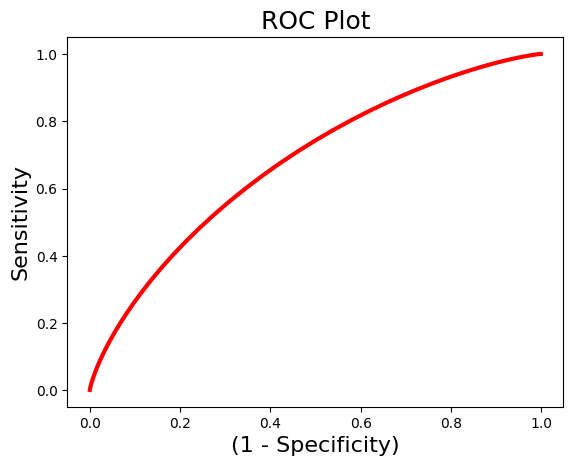

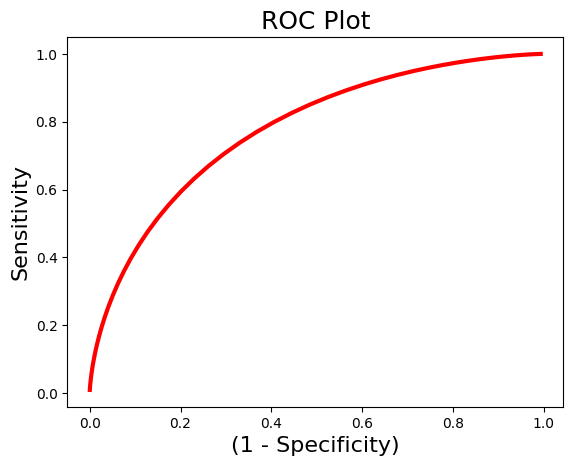

In [53]:
for k in [52]: 
# for k in mask_all.X['Cluster_num']:  
    print('ROI_' + '{:03}'.format(k))
    ROI_mask = mask_all[mask_all.X['Cluster_num'] == k]
    masked_data  = oo_data.apply_mask(ROI_mask)
    masked_data.Y = oo_data.X['Condition']
    svm_stats = masked_data.predict(algorithm='svm', 
                                    cv_dict={'type':'loso', 'subject_id': subject_id},
                                    **{'kernel':"linear"}, plot=False, verbose=0)
    
    roc = Roc(input_values=svm_stats['dist_from_hyperplane_xval'],
            binary_outcome=svm_stats['Y'].astype(bool))
    roc.plot()
    roc.summary()
    
    roc_fc = Roc(input_values=svm_stats['dist_from_hyperplane_xval'],
                        binary_outcome=svm_stats['Y'].astype(bool), forced_choice=subject_id)
    roc_fc.plot()
    roc_fc.summary()

    
#     svm_result_list.append({'ROI': 'ROI_' + "{:03}".format(k), 'CV accuracy': svm_stats['mcr_xval'], \
#                             'ROC_accuracy': roc.accuracy, 'ROC_accuracy_se': roc.accuracy_se, \
#                             'ROC_accuracy_p_value': roc.accuracy_p.pvalue, 'ROC_accuracy_p': roc.accuracy_p,\
#                             'ROC_sensitivity': roc.sensitivity, 'ROC_specificity': roc.specificity, 'ROC_AUC': roc.auc, 'ROC_PPV': roc.ppv,\
#                             'ROC_FC_accuracy': roc_fc.accuracy, 'ROC_FC_accuracy_se': roc_fc.accuracy_se, \
#                             'ROC_FC_accuracy_p_value': roc_fc.accuracy_p.pvalue, 'ROC_FC_accuracy_p': roc_fc.accuracy_p,\
#                             'ROC_FC_sensitivity': roc_fc.sensitivity, \
#                             'ROC_FC_specificity': roc_fc.specificity, 'ROC_FC_AUC': roc_fc.auc, 'ROC_FC_PPV': roc_fc.ppv})



------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           0.57
Accuracy SE:        0.06
Accuracy p-value:   0.25
Sensitivity:        0.39
Specificity:        0.74
AUC:                0.55
PPV:                0.60
------------------------
------------------------
.:ROC Analysis Summary:.
------------------------
Accuracy:           0.50
Accuracy SE:        0.07
Accuracy p-value:   1.00
Sensitivity:        0.55
Specificity:        0.55
AUC:                0.55
PPV:                0.55
------------------------


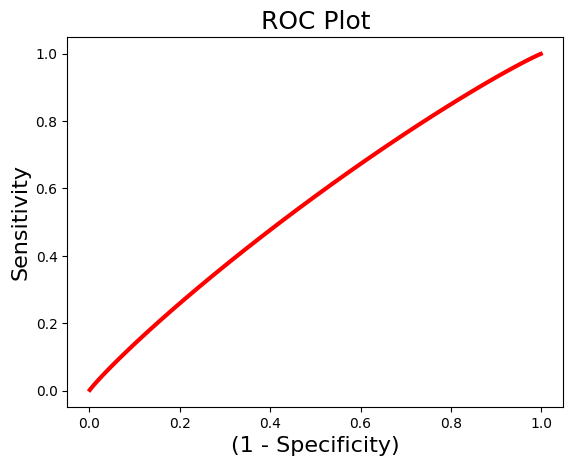

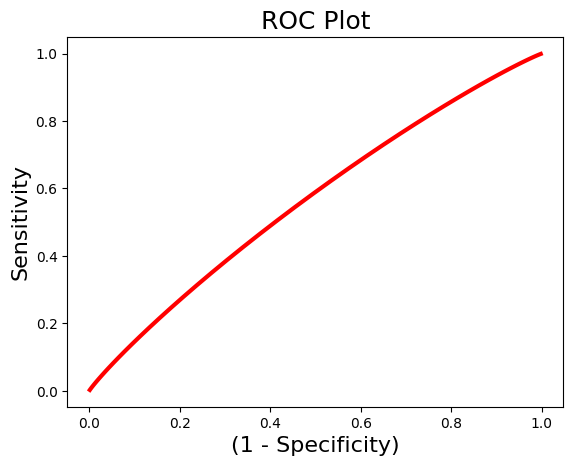

In [54]:
risky_classify_certain = dc_data.similarity(svm_stats['weight_map'],'correlation')

#### cross-situation ROC
cross_roc = Roc(input_values= risky_classify_certain,
                binary_outcome=dc_stats['Y'].astype(bool))
cross_roc.plot()
cross_roc.summary()

cross_roc_fc = Roc(input_values= risky_classify_certain,
                    binary_outcome=dc_stats['Y'].astype(bool), forced_choice=subject_id)
cross_roc_fc.plot()
cross_roc_fc.summary()

### Multiple comparison correction

确定经过多重比较校正后依然显著的脑区，可选fdr校正或Bonferroni校正

In [ ]:
svm_result_df = pd.read_csv(mvpa_path + 'oo_svm_results.csv')
svm_result_df.head()

svm_result_dict = svm_result_df.to_dict(orient = 'records')

p = 0.05
fdr_p = fdr(np.array([x['ROC_FC_accuracy_p_value'] for x in svm_result_dict]), q = p)
bof_p = p / len(svm_result_dict)

print("fdr_p:", fdr_p)
print("bof_p:", bof_p)

In [ ]:
mvpa_acc = Brain_Data([x*y['ROC_FC_accuracy'] for x,y in zip(mask_all, svm_result_dict)]).sum()
mvpa_p = Brain_Data([x*y['ROC_FC_accuracy_p_value'] for x,y in zip(mask_all, svm_result_dict)]).sum()

thresholded = threshold(mvpa_acc, mvpa_p, thr=fdr_p)

plot_glass_brain(thresholded.to_nifti(), cmap='coolwarm') # new firstlevel

thresholded.write(mvpa_path + 'OO2vs8_thresholded_FC.nii.gz')

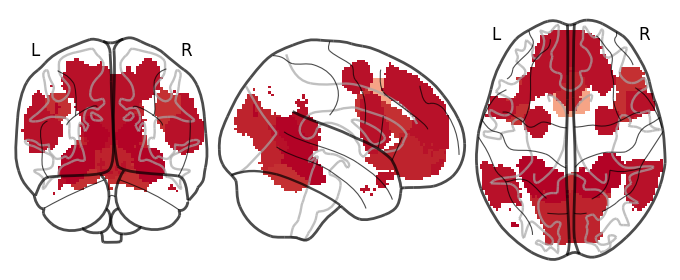

In [20]:
plot_glass_brain(thresholded_fc.to_nifti(), cmap='coolwarm')

# Draw Fig
最后推荐一个画图函数plot_stat_map()，可以自定义坐标（x,y,z）、threshold、值域和颜色

详情可查阅nilearn官网（https://nilearn.github.io/stable/index.html）

https://nilearn.github.io/stable/modules/generated/nilearn.plotting.plot_stat_map.html

In [ ]:
fdr_p = 0.00025

t_items = ['intention'] # 'gratitude', 'allocation', 'cost', 'intention'
sig_roi_list = []

for t_item in t_items:

    thresholded = image.load_img(os.path.join(raw_dir, 'rsa_nii\\single_roi\\', 'dc_roi_052_200c_20240521.nii.gz'))
    thresholded = Brain_Data(thresholded) # nltools data

    plot_stat_map(
        thresholded.to_nifti(),
        bg_img='C:\\Software\\MRIcron\\Resources\\templates\\ch2better.nii.gz',
        black_bg = False,
        cut_coords=(0, 42, 42),
        # cut_coords=None,
        threshold=fdr_p,
        title=None,
        dim=-0.5,
        annotate=False,
        draw_cross = False,
        output_file = raw_dir + "rsa_nii\\single_roi\\dc_roi052_0_42_42_better.svg",
        cmap="hot",
        #cmap="bwr",
        #symmetric_cbar = True,
        vmax = 0.24
    )